# 🚗 DrowsyGuard: Real-Time Driver Fatigue Detection System
**Bina Nusantara University — Computer Vision Project**

Dataset: **NTHU-DDD Multi-Class** (National Tsing Hua University Driver Drowsiness Detection)

- **Phase 1** — Environment Setup & NTHU-DDD Dataset Loading
- **Phase 2** — Feature Extraction (EAR, MAR, Head Pose via PnP)
- **Phase 3** — Rule-Based Fatigue Detection
- **Phase 4** — CNN Classifier (MobileNetV2, 2-phase fine-tuning + class weights)
- **Phase 5** — Evaluation: CNN, Hybrid (OR-fusion) + Sub-class Breakdown
- **Phase 5.5** — Learned Fusion: Logistic Regression meta-learner
- **Phase 5.6** — Temporal Smoothing (deployment utility)
- **Phase 6** — Results Summary, Visualization & Export

> ⚡ **Colab-Friendly**: MediaPipe `FaceLandmarker` task API, tested on Colab T4 GPU.

### NTHU-DDD class structure
```
Multi class/
└── train/
    ├── drowsy/
    │   ├── sleepyCombination/    (17,756 images)
    │   ├── slowBlinkWithNodding/ (9,412  images)
    │   └── yawning/              (8,862  images)
    └── notdrowsy/                (30,491 images)
```
Total: 66,521 images | Binary: Fatigue (36,030) vs NonFatigue (30,491)

### Full inference pipeline
```
Frame → EAR / MAR / PnP  +  MobileNetV2 CNN prob
              ↓
     LR Meta-Learner  (fusion score)   [Phase 5.5]
              ↓
     Temporal Smoother  (W frames)     [Phase 5.6]
              ↓
          🚨 Alert
```


---
## Phase 1 — Environment Setup & Dataset Preparation

In [1]:
# ============================================================
#  Cell 1.1 — Install Dependencies
# ============================================================
!pip install -q mediapipe opencv-python-headless matplotlib seaborn scikit-learn tqdm
!pip install -q tensorflow  # for CNN Phase 4
print('✅ All dependencies installed')

✅ All dependencies installed


In [2]:
# ============================================================
#  Cell 1.2 — Download MediaPipe FaceLandmarker Task Model
# ============================================================
import urllib.request, os

MODEL_URL  = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task'
MODEL_PATH = 'face_landmarker.task'

if not os.path.exists(MODEL_PATH):
    print('Downloading FaceLandmarker model (~20 MB) …')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print('✅ Model downloaded:', MODEL_PATH)
else:
    print('✅ Model already present:', MODEL_PATH)

✅ Model already present: face_landmarker.task


In [3]:
# ============================================================
#  Cell 1.3 — Load NTHU-DDD Dataset (Local / VS Code)
#
#  Set DATASET_ROOT to the folder containing:
#    .../Multi class/train/drowsy/sleepyCombination/*.jpg
#    .../Multi class/train/drowsy/slowBlinkWithNodding/*.jpg
#    .../Multi class/train/drowsy/yawning/*.jpg
#    .../Multi class/train/notdrowsy/*.jpg
# ============================================================
import os, glob

DATASET_ROOT = r'/Users/nikolastjahjadi/Downloads/Model Fatigue/Multi class/train'

SUBCLASSES = {
    'sleepyCombination'   : os.path.join(DATASET_ROOT, 'drowsy', 'sleepyCombination'),
    'slowBlinkWithNodding': os.path.join(DATASET_ROOT, 'drowsy', 'slowBlinkWithNodding'),
    'yawning'             : os.path.join(DATASET_ROOT, 'drowsy', 'yawning'),
}
NOTDROWSY_DIR = os.path.join(DATASET_ROOT, 'notdrowsy')

# ── Validate folders exist ────────────────────────────────────────────────────
for name, folder in list(SUBCLASSES.items()) + [('notdrowsy', NOTDROWSY_DIR)]:
    status = '✅' if os.path.isdir(folder) else '❌ NOT FOUND'
    print(f'   {status}  {name}: {folder}')

# ── Collect paths + sub-class labels ─────────────────────────────────────────
drowsy_imgs = []   # list of (path, subclass_name)

for subclass, folder in SUBCLASSES.items():
    paths = sorted(glob.glob(os.path.join(folder, '*.jpg')))
    drowsy_imgs.extend([(p, subclass) for p in paths])
    print(f'   {subclass:<25}: {len(paths):>6,} images')

nondrowsy_imgs = sorted(glob.glob(os.path.join(NOTDROWSY_DIR, '*.jpg')))
print(f'   {"notdrowsy":<25}: {len(nondrowsy_imgs):>6,} images')
print(f'\n   Total drowsy    : {len(drowsy_imgs):>6,}')
print(f'   Total notdrowsy : {len(nondrowsy_imgs):>6,}')
print(f'   Grand total     : {len(drowsy_imgs)+len(nondrowsy_imgs):>6,}')

# Flat lists for downstream use
fatigue_imgs   = [p for p, _ in drowsy_imgs]
fatigue_subcls = [s for _, s in drowsy_imgs]
nonfatigue_imgs = nondrowsy_imgs


   ✅  sleepyCombination: /Users/nikolastjahjadi/Downloads/Model Fatigue/Multi class/train/drowsy/sleepyCombination
   ✅  slowBlinkWithNodding: /Users/nikolastjahjadi/Downloads/Model Fatigue/Multi class/train/drowsy/slowBlinkWithNodding
   ✅  yawning: /Users/nikolastjahjadi/Downloads/Model Fatigue/Multi class/train/drowsy/yawning
   ✅  notdrowsy: /Users/nikolastjahjadi/Downloads/Model Fatigue/Multi class/train/notdrowsy
   sleepyCombination        : 17,756 images
   slowBlinkWithNodding     :  9,412 images
   yawning                  :  8,862 images
   notdrowsy                : 30,491 images

   Total drowsy    : 36,030
   Total notdrowsy : 30,491
   Grand total     : 66,521


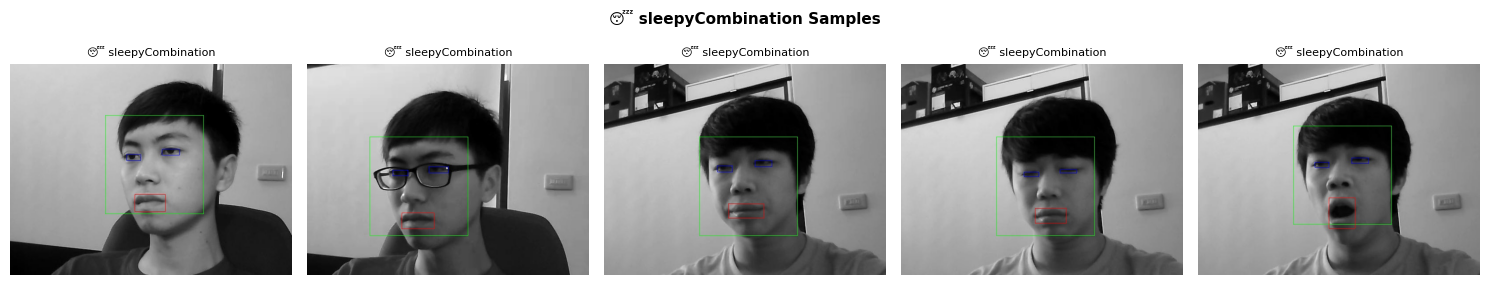

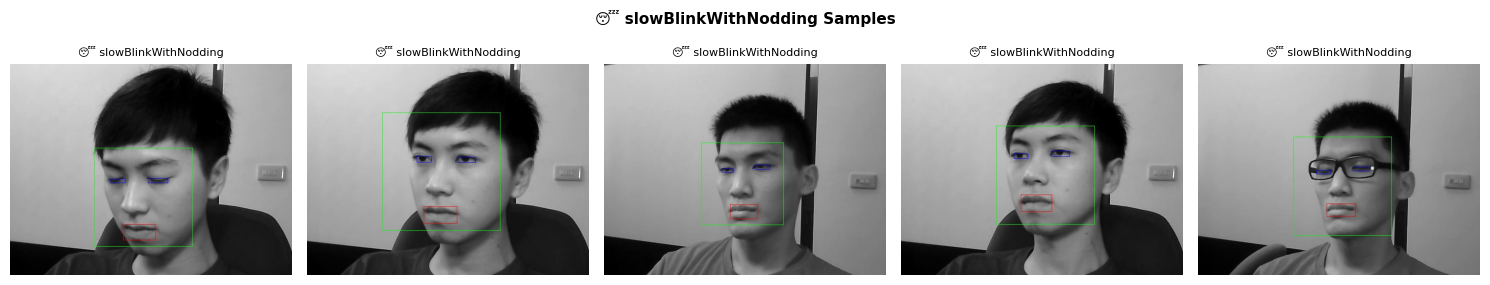

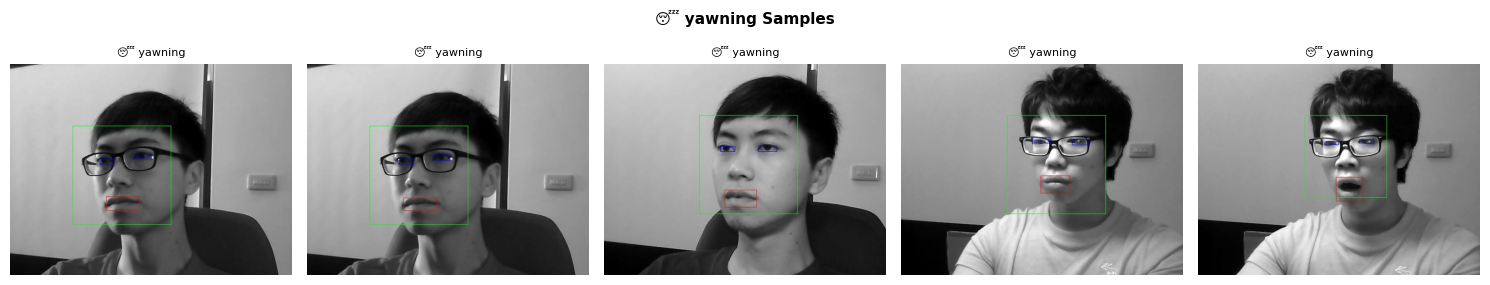

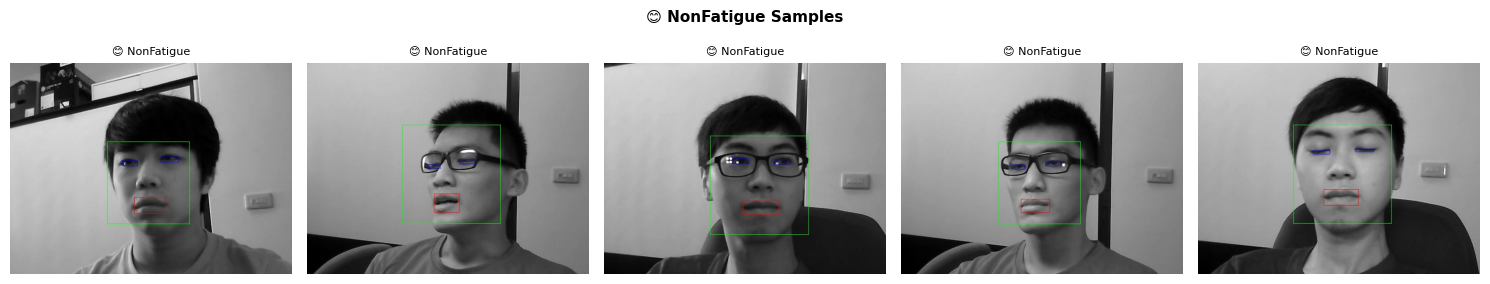

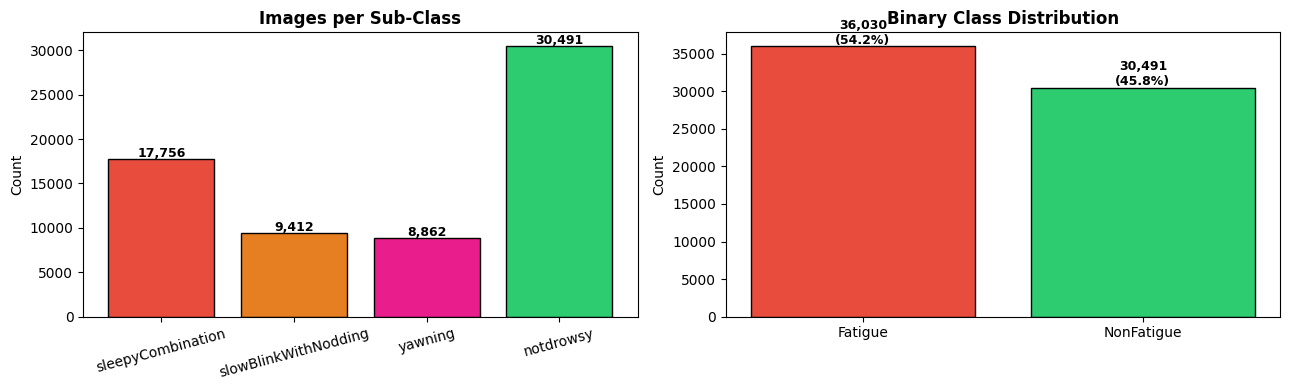


✅ Dataset loaded — 66,521 total images
   Class balance: 54.2% Fatigue / 45.8% NonFatigue


In [4]:
# ============================================================
#  Cell 1.4 — Dataset Preview & Class Distribution
# ============================================================
import cv2, random, matplotlib.pyplot as plt, numpy as np

def show_samples(paths, label, n=5):
    sample = random.sample(paths, min(n, len(paths)))
    fig, axes = plt.subplots(1, len(sample), figsize=(15, 3))
    for ax, p in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.set_title(label, fontsize=8); ax.axis('off')
    plt.suptitle(f'{label} Samples', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

random.seed(42)
for subclass, folder in SUBCLASSES.items():
    paths = [p for p, s in drowsy_imgs if s == subclass]
    show_samples(paths, f'😴 {subclass}')
show_samples(nonfatigue_imgs, '😊 NonFatigue')

# ── Distribution bar chart ────────────────────────────────────────────────────
subclass_counts = {s: sum(1 for _, sc in drowsy_imgs if sc == s) for s in SUBCLASSES}
subclass_counts['notdrowsy'] = len(nondrowsy_imgs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per sub-class
colors = ['#e74c3c','#e67e22','#e91e8c','#2ecc71']
bars = axes[0].bar(subclass_counts.keys(), subclass_counts.values(),
                   color=colors, edgecolor='black')
axes[0].set_title('Images per Sub-Class', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')

# Binary
axes[1].bar(['Fatigue','NonFatigue'], [len(fatigue_imgs), len(nonfatigue_imgs)],
            color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[1].set_title('Binary Class Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
total = len(fatigue_imgs) + len(nonfatigue_imgs)
for bar in axes[1].patches:
    pct = bar.get_height() / total * 100
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                 f'{int(bar.get_height()):,}\n({pct:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()
print(f'\n✅ Dataset loaded — {total:,} total images')
print(f'   Class balance: {len(fatigue_imgs)/total*100:.1f}% Fatigue / {len(nonfatigue_imgs)/total*100:.1f}% NonFatigue')


---
## Phase 2 — Feature Extraction with MediaPipe FaceLandmarker

We compute three geometric features per image:
| Feature | Description |
|---|---|
| **EAR** | Eye Aspect Ratio — measures eye openness |
| **MAR** | Mouth Aspect Ratio — detects yawning |
| **Head Pitch** | Vertical head tilt — detects nodding |

Landmark indices follow MediaPipe's 478-point face mesh.

In [5]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# --- EAR landmark indices (MediaPipe 478-point mesh) ---
# Each eye: [p1, p2, p3, p4, p5, p6]
# p1/p4 = horizontal corners; p2,p3/p5,p6 = vertical pairs
LEFT_EYE  = [362, 385, 387, 263, 373, 380]   # left eye (from viewer)
RIGHT_EYE = [33,  160, 158, 133, 153, 144]   # right eye (from viewer)

# --- MAR landmark indices ---
MOUTH = [61, 291, 39, 181, 0, 17, 269, 405]  # [left, right, top1, top2, top3, bot1, bot2, bot3]

# --- Head pose reference points (PnP) ---
# Nose tip, chin, left eye corner, right eye corner, left mouth, right mouth
HEAD_POSE_IDX = [1, 152, 226, 446, 57, 287]

print('✅ Landmark indices defined')
print(f'   LEFT_EYE  : {LEFT_EYE}')
print(f'   RIGHT_EYE : {RIGHT_EYE}')
print(f'   MOUTH     : {MOUTH}')

✅ Landmark indices defined
   LEFT_EYE  : [362, 385, 387, 263, 373, 380]
   RIGHT_EYE : [33, 160, 158, 133, 153, 144]
   MOUTH     : [61, 291, 39, 181, 0, 17, 269, 405]


In [6]:
# ============================================================
#  Cell 2.2 — EAR / MAR / Head Pose Functions
#  HEAD POSE: upgraded to proper PnP (Perspective-n-Point) solving
#  instead of the previous 2-D proxy approximation.
#  This gives true pitch/yaw/roll angles in degrees.
# ============================================================
import numpy as np
from scipy.spatial import distance as dist

def euclidean(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def compute_EAR(landmarks, eye_idx, img_w, img_h):
    """Eye Aspect Ratio (Soukupova & Cech, 2016).
    EAR = (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)
    """
    pts = [(landmarks[i].x * img_w, landmarks[i].y * img_h) for i in eye_idx]
    A = euclidean(pts[1], pts[5])
    B = euclidean(pts[2], pts[4])
    C = euclidean(pts[0], pts[3])
    return (A + B) / (2.0 * C + 1e-6)

def compute_MAR(landmarks, mouth_idx, img_w, img_h):
    """Mouth Aspect Ratio for yawn detection.
    MAR = mean(vertical distances) / horizontal distance
    """
    pts = [(landmarks[i].x * img_w, landmarks[i].y * img_h) for i in mouth_idx]
    horizontal = euclidean(pts[0], pts[1])
    v1 = euclidean(pts[2], pts[5])
    v2 = euclidean(pts[3], pts[6])
    v3 = euclidean(pts[4], pts[7])
    return (v1 + v2 + v3) / (3.0 * horizontal + 1e-6)

# ── PnP Head Pose ─────────────────────────────────────────────────────────────
# Generic 3-D face model in canonical coordinates (mm, frontal face).
# 6 anchor points: nose tip, chin, left eye outer, right eye outer,
#                  left mouth corner, right mouth corner.
# These match HEAD_POSE_IDX = [1, 152, 226, 446, 57, 287]
FACE_3D_MODEL = np.array([
    [  0.0,    0.0,    0.0   ],   # 1   — nose tip
    [  0.0,  -63.6,  -12.5  ],   # 152 — chin
    [-43.3,   32.7,  -26.0  ],   # 226 — left eye outer corner
    [ 43.3,   32.7,  -26.0  ],   # 446 — right eye outer corner
    [-28.9,  -28.9,  -24.1  ],   # 57  — left mouth corner
    [ 28.9,  -28.9,  -24.1  ],   # 287 — right mouth corner
], dtype=np.float64)

# Distortion coefficients — assume no lens distortion (valid for webcam footage)
DIST_COEFFS = np.zeros((4, 1), dtype=np.float64)

def compute_head_pose_pnp(landmarks, img_w, img_h):
    """Estimate head pitch, yaw, roll via solvePnP (Perspective-n-Point).

    Returns (pitch, yaw, roll) in degrees:
      - pitch > 0  → nodding down  (chin toward chest)
      - yaw   > 0  → turning right
      - roll  > 0  → tilting right shoulder

    Falls back to (0, 0, 0) if solvePnP fails (degenerate pose).
    """
    # Build camera intrinsic matrix from image size (pinhole approximation)
    focal   = img_w                          # focal length ≈ image width
    cx, cy  = img_w / 2.0, img_h / 2.0
    cam_mat = np.array([
        [focal, 0,     cx],
        [0,     focal, cy],
        [0,     0,     1 ]
    ], dtype=np.float64)

    # 2-D image points for the 6 anchor landmarks
    img_pts = np.array([
        [landmarks[1  ].x * img_w, landmarks[1  ].y * img_h],
        [landmarks[152].x * img_w, landmarks[152].y * img_h],
        [landmarks[226].x * img_w, landmarks[226].y * img_h],
        [landmarks[446].x * img_w, landmarks[446].y * img_h],
        [landmarks[57 ].x * img_w, landmarks[57 ].y * img_h],
        [landmarks[287].x * img_w, landmarks[287].y * img_h],
    ], dtype=np.float64)

    success, rvec, tvec = cv2.solvePnP(
        FACE_3D_MODEL, img_pts, cam_mat, DIST_COEFFS,
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not success:
        return 0.0, 0.0, 0.0

    # Convert rotation vector → rotation matrix → Euler angles
    rmat, _ = cv2.Rodrigues(rvec)
    # Decompose into pitch (x), yaw (y), roll (z) via projectMatrix
    angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
    pitch, yaw, roll = angles[0], angles[1], angles[2]
    return float(pitch), float(yaw), float(roll)

print('✅ EAR / MAR / PnP Head Pose functions defined')
print('   Head pose now uses cv2.solvePnP — proper 3-D Euler angles')


✅ EAR / MAR / PnP Head Pose functions defined
   Head pose now uses cv2.solvePnP — proper 3-D Euler angles


In [7]:
# ============================================================
#  Cell 2.3 — Build MediaPipe FaceLandmarker (IMAGE mode)
# ============================================================
BaseOptions       = mp_python.BaseOptions
FaceLandmarker    = mp_vision.FaceLandmarker
FaceLandmarkerOptions = mp_vision.FaceLandmarkerOptions
VisionRunningMode = mp_vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)

detector = FaceLandmarker.create_from_options(options)
print('✅ FaceLandmarker created (IMAGE mode)')

✅ FaceLandmarker created (IMAGE mode)


I0000 00:00:1779355171.494870 3103133 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1779355171.497536 3103133 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779355171.586503 3103133 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779355171.594427 3103136 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779355171.608270 3103135 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [8]:
# ============================================================
#  Cell 2.4 — Run Feature Extraction on Entire Dataset
#  Extracts: EAR, MAR, HeadPitch, HeadYaw, HeadRoll
#  Also stores subclass label for NTHU-DDD sub-analysis
#
#  ⚠️  ~66k images — takes ~30-45 min on Colab T4
#  Saves CSV after each class so progress is not lost
# ============================================================
from tqdm import tqdm
import pandas as pd, os

FEATURE_CSV = 'drowsyguard_features.csv'

def extract_features_from_image(img_path):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result   = detector.detect(mp_image)
    if not result.face_landmarks: return None

    lm        = result.face_landmarks[0]
    left_ear  = compute_EAR(lm, LEFT_EYE,  w, h)
    right_ear = compute_EAR(lm, RIGHT_EYE, w, h)
    ear       = (left_ear + right_ear) / 2.0
    mar       = compute_MAR(lm, MOUTH, w, h)
    pitch, yaw, roll = compute_head_pose_pnp(lm, w, h)
    return (ear, mar, pitch, yaw, roll)

def build_feature_dataset(img_paths, label, subclasses, desc):
    """subclasses: list of subclass name per path (or None for notdrowsy)"""
    records, failed = [], 0
    for i, p in enumerate(tqdm(img_paths, desc=desc)):
        feat = extract_features_from_image(p)
        if feat:
            ear, mar, pitch, yaw, roll = feat
            records.append({
                'path': p, 'EAR': ear, 'MAR': mar,
                'HeadPitch': pitch, 'HeadYaw': yaw, 'HeadRoll': roll,
                'label': label,
                'subclass': subclasses[i] if subclasses else 'notdrowsy'
            })
        else:
            failed += 1
    print(f'   ✅ {len(records):,} extracted  |  ⚠️  {failed:,} no-face skipped')
    return records

# ── Check if CSV already exists (resume support) ─────────────────────────────
if os.path.exists(FEATURE_CSV):
    print(f'📂 Found existing {FEATURE_CSV} — loading instead of re-extracting')
    df = pd.read_csv(FEATURE_CSV)
    print(f'   Shape: {df.shape}  |  Columns: {list(df.columns)}')
else:
    print('🔄 Extracting features from scratch...')
    records_fatigue    = build_feature_dataset(
        fatigue_imgs, 1, fatigue_subcls, '😴 Fatigue (all sub-classes)')
    records_nonfatigue = build_feature_dataset(
        nonfatigue_imgs, 0, None, '😊 NonFatigue')

    df = pd.DataFrame(records_fatigue + records_nonfatigue)
    df['label_str'] = df['label'].map({1:'Fatigue', 0:'NonFatigue'})
    df.to_csv(FEATURE_CSV, index=False)
    print(f'\n✅ Saved to {FEATURE_CSV}')

df['label_str'] = df['label'].map({1:'Fatigue', 0:'NonFatigue'})
print(f'\n📊 Feature DataFrame: {df.shape}')
print(df.groupby(['label_str','subclass']).size().reset_index(name='count').to_string(index=False))


🔄 Extracting features from scratch...


😴 Fatigue (all sub-classes):  64%|██████▎   | 22932/36030 [01:59<01:08, 192.05it/s]E0000 00:00:1779355291.642698 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
😴 Fatigue (all sub-classes):  95%|█████████▌| 34383/36030 [02:59<00:08, 192.66it/s]E0000 00:00:1779355351.644517 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
😴 Fatigue (all sub-classes): 100%|██████████| 36030/36030 [03:08<00:00, 191.15it/s]


   ✅ 36,011 extracted  |  ⚠️  19 no-face skipped


😊 NonFatigue:  32%|███▏      | 9896/30491 [00:51<01:46, 192.65it/s]E0000 00:00:1779355411.645283 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
😊 NonFatigue:  70%|███████   | 21350/30491 [01:51<00:47, 191.74it/s]E0000 00:00:1779355471.650579 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
😊 NonFatigue: 100%|██████████| 30491/30491 [02:39<00:00, 191.37it/s]


   ✅ 29,697 extracted  |  ⚠️  794 no-face skipped

✅ Saved to drowsyguard_features.csv

📊 Feature DataFrame: (65708, 9)
 label_str             subclass  count
   Fatigue    sleepyCombination  17747
   Fatigue slowBlinkWithNodding   9402
   Fatigue              yawning   8862
NonFatigue            notdrowsy  29697


In [9]:
# ============================================================
#  Cell 2.5 — Save Feature CSV (for fast re-use)
# ============================================================
import os

# CSV disimpan di folder yang sama dengan notebook ini
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
FEATURE_CSV  = os.path.join(NOTEBOOK_DIR, 'drowsyguard_features.csv')

df.to_csv(FEATURE_CSV, index=False)
print(f'✅ Features saved to: {FEATURE_CSV}')
print(f'   Shape : {df.shape}')
print(f'   Size  : {os.path.getsize(FEATURE_CSV)/1024/1024:.1f} MB')
df.describe().round(4)


✅ Features saved to: /Users/nikolastjahjadi/Downloads/Model Fatigue/drowsyguard_features.csv
   Shape : (65708, 9)
   Size  : 15.6 MB


,EAR,MAR,HeadPitch,HeadYaw,HeadRoll,label
count,65708.0000,65708.0000,65708.0000,65708.0000,65708.0000,65708.0000
mean,0.2327,0.6373,124.2295,20.6843,-1.1775,0.5480
std,0.0876,0.1007,112.4159,8.1793,36.5781,0.4977
min,0.0106,0.3904,-179.9966,-86.7648,-179.9998,0.0000
25%,0.1648,0.5783,159.5228,17.1151,-4.4057,0.0000
50%,0.2396,0.6179,166.3387,21.1017,-2.2622,1.0000
75%,0.2999,0.6652,171.5435,24.4703,-0.0486,1.0000
max,2.5263,2.3849,179.9995,81.8626,180.0000,1.0000


---
## Phase 3 — Rule-Based Fatigue Detection

Implements the thresholding logic from the proposal:
- **EAR < 0.25** → eye closure event
- **PERCLOS > 0.15** → drowsy (primary indicator)
- **MAR > 0.6** → yawn event (secondary indicator)
- **Head Pitch > 15°** → head nodding

For the static image dataset, PERCLOS is estimated per-image using EAR thresholding.

In [10]:
# ============================================================
#  Cell 3.1 — Define Thresholds & Rule-Based Classifier
# ============================================================

EAR_THRESHOLD   = 0.25   # below → eye closure
MAR_THRESHOLD   = 0.60   # above → yawn
PITCH_THRESHOLD = 15.0   # degrees; above → head nod

def rule_based_predict(row):
    """Multi-feature rule-based fatigue prediction.
    Returns 1 (Fatigue) if any primary indicator triggers,
    or if two secondary indicators trigger simultaneously.
    """
    ear_low  = row['EAR']       < EAR_THRESHOLD
    yawning  = row['MAR']       > MAR_THRESHOLD
    nodding  = row['HeadPitch'] > PITCH_THRESHOLD

    # Primary: EAR below threshold (eye closure)
    if ear_low:
        return 1
    # Secondary: two or more secondary indicators
    if yawning and nodding:
        return 1
    return 0

df['rule_pred'] = df.apply(rule_based_predict, axis=1)
print('✅ Rule-based predictions computed')
print(df[['EAR','MAR','HeadPitch','label','rule_pred']].head(10).round(4))

✅ Rule-based predictions computed
      EAR     MAR  HeadPitch  label  rule_pred
0  0.3035  0.6592   168.2815      1          1
1  0.3087  0.6517   167.1448      1          1
2  0.3523  0.6426   167.8555      1          1
3  0.3368  0.6780   168.3653      1          1
4  0.3362  0.6577   167.0744      1          1
5  0.3280  0.6591   167.4428      1          1
6  0.3563  0.6557   167.9135      1          1
7  0.3568  0.6703   167.9778      1          1
8  0.3554  0.6662   167.9819      1          1
9  0.3678  0.6382   167.7897      1          1


In [11]:
# ============================================================
#  Cell 3.2 — Rule-Based Evaluation Metrics
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

y_true = df['label'].values
y_rule = df['rule_pred'].values

acc  = accuracy_score(y_true, y_rule)
prec = precision_score(y_true, y_rule, zero_division=0)
rec  = recall_score(y_true, y_rule, zero_division=0)
f1   = f1_score(y_true, y_rule, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_rule).ravel()
fpr  = fp / (fp + tn + 1e-6)

print('=' * 50)
print('📋  RULE-BASED CLASSIFIER METRICS')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}  (target ≥ 0.90)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}  (target ≥ 0.88)')
print(f'  FPR       : {fpr:.4f}  (target ≤ 0.05)')
print(f'  TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print('=' * 50)
print(classification_report(y_true, y_rule, target_names=['NonFatigue','Fatigue']))

📋  RULE-BASED CLASSIFIER METRICS
  Accuracy  : 0.5815  (target ≥ 0.90)
  Precision : 0.5757
  Recall    : 0.8986
  F1-Score  : 0.7018  (target ≥ 0.88)
  FPR       : 0.8031  (target ≤ 0.05)
  TP=32361  FP=23851  TN=5846  FN=3650
              precision    recall  f1-score   support

  NonFatigue       0.62      0.20      0.30     29697
     Fatigue       0.58      0.90      0.70     36011

    accuracy                           0.58     65708
   macro avg       0.60      0.55      0.50     65708
weighted avg       0.59      0.58      0.52     65708



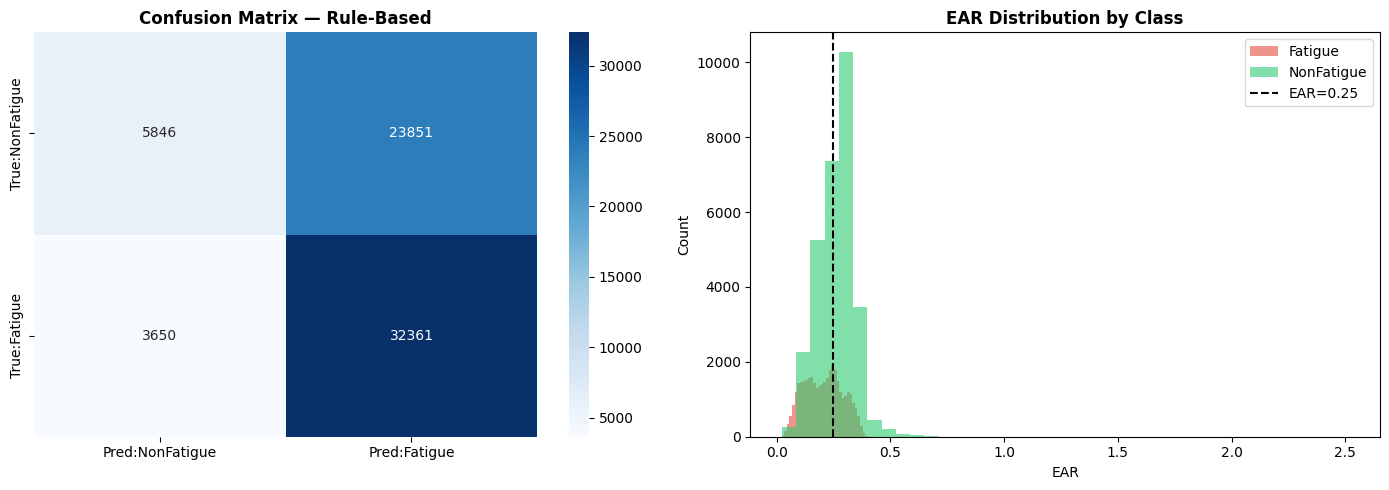

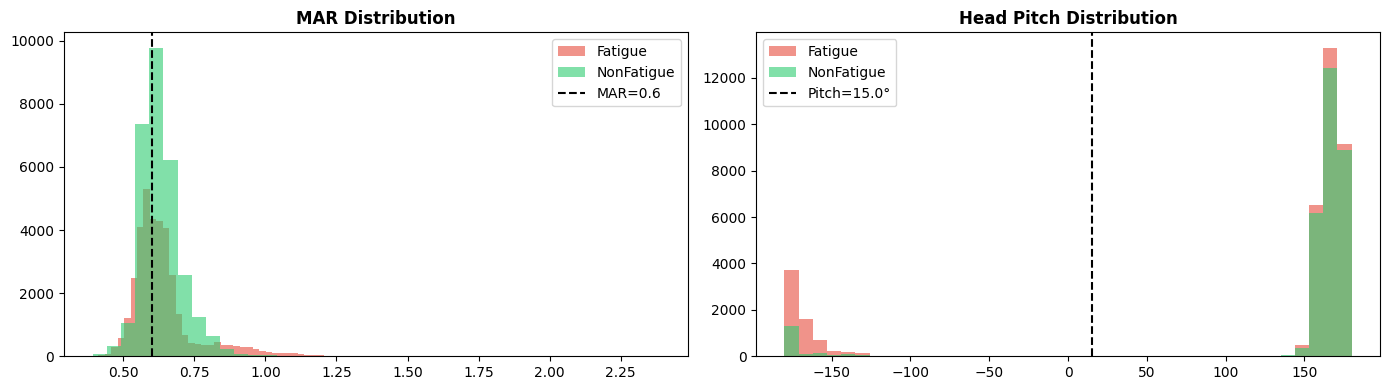

In [12]:
# ============================================================
#  Cell 3.3 — Confusion Matrix & Feature Distribution Plots
# ============================================================
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_rule)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred:NonFatigue','Pred:Fatigue'],
            yticklabels=['True:NonFatigue','True:Fatigue'])
axes[0].set_title('Confusion Matrix — Rule-Based', fontweight='bold')

# --- EAR Distribution ---
for label, color in [('Fatigue','#e74c3c'), ('NonFatigue','#2ecc71')]:
    subset = df[df['label_str'] == label]['EAR']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=label)
axes[1].axvline(EAR_THRESHOLD, color='black', linestyle='--', label=f'EAR={EAR_THRESHOLD}')
axes[1].set_xlabel('EAR'); axes[1].set_ylabel('Count')
axes[1].set_title('EAR Distribution by Class', fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()

# --- MAR & Head Pitch ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, color in [('Fatigue','#e74c3c'), ('NonFatigue','#2ecc71')]:
    axes[0].hist(df[df['label_str']==label]['MAR'], bins=40, alpha=0.6, color=color, label=label)
    axes[1].hist(df[df['label_str']==label]['HeadPitch'], bins=40, alpha=0.6, color=color, label=label)
axes[0].axvline(MAR_THRESHOLD, color='black', linestyle='--', label=f'MAR={MAR_THRESHOLD}')
axes[1].axvline(PITCH_THRESHOLD, color='black', linestyle='--', label=f'Pitch={PITCH_THRESHOLD}°')
for ax, title in zip(axes, ['MAR Distribution', 'Head Pitch Distribution']):
    ax.set_title(title, fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

---
## Phase 4 — CNN Classifier (MobileNetV2 Fine-Tuning)

A lightweight MobileNetV2 is fine-tuned on the Fatigue Dataset as described in the proposal's Phase 4 roadmap. This serves as a learned complement to the geometric rule-based system.

In [13]:
# ============================================================
#  Cell 4.1 — CNN Data Preparation
#  TEMPORAL SPLIT per subject per subclass:
#  - Split dilakukan per kombinasi (subject × subclass)
#  - 70% frame awal → train, 15% tengah → val, 15% akhir → test
#  - Semua subject & semua subclass terwakili di setiap split
#  - Mencegah subclass hilang akibat urutan rekaman
# ============================================================
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import numpy as np
import os
import pandas as pd

IMG_SIZE = (128, 128)
BATCH    = 64
SEED     = 42

# ── Extract subject ID & frame number ────────────────────────────────────────
def get_subject_id(path):
    return os.path.basename(path).split('_')[0]

def get_frame_number(path):
    try:
        return int(os.path.basename(path).split('_')[3])
    except:
        return 0

df['subject_id']   = df['path'].apply(get_subject_id)
df['frame_number'] = df['path'].apply(get_frame_number)

subjects   = sorted(df['subject_id'].unique())
subclasses = sorted(df['subclass'].unique())
print(f'📋 Subjects  : {subjects}')
print(f'📋 Subclasses: {subclasses}')
print()

# ── Temporal split per subject × subclass ────────────────────────────────────
train_rows, val_rows, test_rows = [], [], []
missing = []

for subj in subjects:
    for subc in subclasses:
        mask   = (df['subject_id'] == subj) & (df['subclass'] == subc)
        df_grp = df[mask].sort_values('frame_number').reset_index(drop=True)
        n      = len(df_grp)

        if n == 0:
            missing.append(f'{subj}/{subc}')
            continue

        n_test  = max(1, int(n * 0.15))
        n_val   = max(1, int(n * 0.15))
        n_train = n - n_val - n_test

        train_rows.append(df_grp.iloc[:n_train])
        val_rows.append(df_grp.iloc[n_train:n_train + n_val])
        test_rows.append(df_grp.iloc[n_train + n_val:])

        print(f'   {subj}/{subc:<28}: {n:>5,} → '
              f'train={n_train:,} | val={n_val:,} | test={n_test:,}')

if missing:
    print(f'\n⚠️  No data for combinations: {missing}')

df_train = pd.concat(train_rows).reset_index(drop=True)
df_val   = pd.concat(val_rows).reset_index(drop=True)
df_test  = pd.concat(test_rows).reset_index(drop=True)

# ── Oversample yawning in train set ─────────────────────────────────────────
# Yawning frames are fewer and harder to detect — upsample to match
# sleepyCombination count so model gets more exposure to yawning patterns.
# This only affects train set, val/test untouched.
from sklearn.utils import resample

df_yawning_train = df_train[df_train['subclass'] == 'yawning']
df_sleepy_train  = df_train[df_train['subclass'] == 'sleepyCombination']

if len(df_yawning_train) > 0 and len(df_sleepy_train) > 0:
    target_n = len(df_sleepy_train)
    df_yawning_up = resample(
        df_yawning_train,
        replace=True,
        n_samples=target_n,
        random_state=SEED
    )
    df_train = pd.concat([df_train, df_yawning_up]).reset_index(drop=True)
    print(f'✅ Yawning oversampled: {len(df_yawning_train):,} → {target_n:,} '
          f'(+{target_n - len(df_yawning_train):,} synthetic frames)')
else:
    print('⚠️  Skipping oversample — yawning or sleepyCombination not found in train')

# Shuffle train (val/test kept in order)
df_train = df_train.sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train, y_train = df_train['path'].tolist(), df_train['label'].tolist()
X_val,   y_val   = df_val['path'].tolist(),   df_val['label'].tolist()
X_test,  y_test  = df_test['path'].tolist(),  df_test['label'].tolist()

sc_train = df_train['subclass'].tolist()
sc_val   = df_val['subclass'].tolist()
sc_test  = df_test['subclass'].tolist()

print(f'\n✅ Temporal split (per subject × subclass):')
print(f'   Train : {len(X_train):>6,} frames')
print(f'   Val   : {len(X_val):>6,} frames')
print(f'   Test  : {len(X_test):>6,} frames')

# ── Verify no frame overlap ───────────────────────────────────────────────────
assert not set(X_train) & set(X_val),  '❌ Train/Val overlap!'
assert not set(X_train) & set(X_test), '❌ Train/Test overlap!'
assert not set(X_val)   & set(X_test), '❌ Val/Test overlap!'
print('\n✅ No frame overlap between splits')

# ── Subclass distribution per split ──────────────────────────────────────────
print()
for name, df_s in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_fat = df_s['label'].sum()
    n_non = len(df_s) - n_fat
    print(f'   {name} ({len(df_s):,}): '
          f'Fatigue={n_fat:,} ({n_fat/len(df_s)*100:.1f}%)  '
          f'NonFatigue={n_non:,} ({n_non/len(df_s)*100:.1f}%)')
    sc_counts = df_s['subclass'].value_counts()
    for sc, cnt in sc_counts.items():
        print(f'      {sc:<28}: {cnt:,}')

# ── Class weights ─────────────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array(y_train)
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f'\n⚖️  Class weights: '
      f'NonFatigue={class_weights_arr[0]:.3f}, '
      f'Fatigue={class_weights_arr[1]:.3f}')


📋 Subjects  : ['001', '002', '005', '006']
📋 Subclasses: ['notdrowsy', 'sleepyCombination', 'slowBlinkWithNodding', 'yawning']

   001/notdrowsy                   : 9,289 → train=6,503 | val=1,393 | test=1,393
   001/sleepyCombination           : 4,524 → train=3,168 | val=678 | test=678
   001/slowBlinkWithNodding        : 2,363 → train=1,655 | val=354 | test=354
   001/yawning                     : 2,683 → train=1,879 | val=402 | test=402
   002/notdrowsy                   : 7,713 → train=5,401 | val=1,156 | test=1,156
   002/sleepyCombination           : 4,983 → train=3,489 | val=747 | test=747
   002/slowBlinkWithNodding        : 2,909 → train=2,037 | val=436 | test=436
   002/yawning                     : 2,704 → train=1,894 | val=405 | test=405
   005/notdrowsy                   : 8,800 → train=6,160 | val=1,320 | test=1,320
   005/sleepyCombination           : 5,670 → train=3,970 | val=850 | test=850
   005/slowBlinkWithNodding        : 3,937 → train=2,757 | val=590 | test=590
  

In [14]:
# ============================================================
#  Cell 4.2 — Build tf.data Pipelines
#
#  Augmentation is LIGHTER than Rihab Kaci version because
#  NTHU-DDD already has diverse conditions built-in:
#  - Multiple subjects, lighting, eyewear, head poses
#  Heavy aug on diverse data can hurt more than help.
#  Random erasing kept (occlusion sim), noise removed.
# ============================================================

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def _apply_erase(img):
    ph = tf.random.uniform((), minval=int(IMG_SIZE[0]*0.10),
                           maxval=int(IMG_SIZE[0]*0.30), dtype=tf.int32)
    pw = tf.random.uniform((), minval=int(IMG_SIZE[1]*0.10),
                           maxval=int(IMG_SIZE[1]*0.30), dtype=tf.int32)
    py = tf.random.uniform((), minval=0, maxval=IMG_SIZE[0]-ph, dtype=tf.int32)
    px = tf.random.uniform((), minval=0, maxval=IMG_SIZE[1]-pw, dtype=tf.int32)
    mask = 1.0 - tf.pad(
        tf.ones((ph, pw, 3), dtype=tf.float32),
        [[py, IMG_SIZE[0]-py-ph], [px, IMG_SIZE[1]-px-pw], [0,0]])
    return img * mask + 0.5 * (1.0 - mask)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    # Random erasing: 40% chance (lighter than before)
    img = tf.cond(
        tf.random.uniform(()) > 0.6,
        true_fn=lambda: _apply_erase(img),
        false_fn=lambda: img
    )
    return tf.clip_by_value(img, 0.0, 1.0), label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
            .map(augment,             num_parallel_calls=AUTOTUNE)
            .shuffle(2048, seed=SEED)
            .batch(BATCH)
            .prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
          .batch(BATCH)
          .prefetch(AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
           .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH)
           .prefetch(AUTOTUNE))

print('✅ tf.data pipelines ready')
print(f'   Train batches : {len(train_ds)}')
print(f'   Val batches   : {len(val_ds)}')
print(f'   Test batches  : {len(test_ds)}')
print('   Augmentations : flip | brightness | contrast | saturation | random-erase (40%)')


✅ tf.data pipelines ready
   Train batches : 914
   Val batches   : 154
   Test batches  : 154
   Augmentations : flip | brightness | contrast | saturation | random-erase (40%)


In [15]:
# ============================================================
#  Cell 4.3 — Build MobileNetV2 Model
#  Slightly larger classification head than Rihab version
#  (more data → can support more parameters without overfitting)
# ============================================================
def build_model():
    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979,649 (11.37 MB)

 Trainable params: 721,665 (2.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# ============================================================
#  Cell 4.4 — Phase A: Train Head Layers (frozen base)
#  Monitor val_loss (bukan val_auc) supaya tidak stop prematur
#  pada cross-subject scenario
# ============================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True,
        monitor='val_loss', mode='min'),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3,
        monitor='val_loss', min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'drowsyguard_best.h5', save_best_only=True,
        monitor='val_loss', mode='min', verbose=0),
]

history_a = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print('✅ Phase A complete')
print(f'   Best val_loss : {min(history_a.history["val_loss"]):.4f}')
print(f'   Best val_acc  : {max(history_a.history["val_accuracy"]):.4f}')


Epoch 1/10
 72/914 ━━━━━━━━━━━━━━━━━━━━ 1:27 104ms/step - accuracy: 0.5594 - auc: 0.5775 - loss: 0.7631 - precision: 0.6904 - recall: 0.5609

E0000 00:00:1779355531.650944 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


592/914 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.6898 - auc: 0.7573 - loss: 0.5794 - precision: 0.7935 - recall: 0.6964

E0000 00:00:1779355591.655685 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


913/914 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7165 - auc: 0.7907 - loss: 0.5405 - precision: 0.8120 - recall: 0.7250

...

E0000 00:00:1779356011.722785 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


767/914 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.8772 - auc: 0.9534 - loss: 0.2740 - precision: 0.9227 - recall: 0.8826

E0000 00:00:1779356071.737045 3103134 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T16:35:31.640477+07:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


914/914 ━━━━━━━━━━━━━━━━━━━━ 153s 166ms/step - accuracy: 0.8781 - auc: 0.9546 - loss: 0.2701 - precision: 0.9250 - recall: 0.8822 - val_accuracy: 0.9381 - val_auc: 0.9826 - val_loss: 0.1977 - val_precision: 0.9696 - val_recall: 0.9157 - learning_rate: 0.0010
Epoch 5/10
913/914 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8832 - auc: 0.9590 - loss: 0.2567 - precision: 0.9295 - recall: 0.8857

914/914 ━━━━━━━━━━━━━━━━━━━━ 154s 167ms/step - accuracy: 0.8857 - auc: 0.9599 - loss: 0.2540 - precision: 0.9308 - recall: 0.8886 - val_accuracy: 0.9508 - val_auc: 0.9851 - val_loss: 0.1484 - val_precision: 0.9659 - val_recall: 0.9435 - learning_rate: 0.0010
Epoch 6/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 156s 170ms/step - accuracy: 0.8910 - auc: 0.9638 - loss: 0.2415 - precision: 0.9337 - recall: 0.8943 - val_accuracy: 0.9312 - val_auc: 0.9867 - val_loss: 0.1872 - val_precision: 0.9745 - val_recall: 0.8979 - learning_rate: 0.0010
Epoch 7/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 154s 167ms/step - accuracy: 0.8932 - auc: 0.9657 - loss: 0.2347 - precision: 0.9363 - recall: 0.8950 - val_accuracy: 0.9312 - val_auc: 0.9805 - val_loss: 0.1985 - val_precision: 0.9620 - val_recall: 0.9103 - learning_rate: 0.0010
Epoch 8/10
913/914 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8991 - auc: 0.9680 - loss: 0.2280 - precision: 0.9389 - recall: 0.9019
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000

In [17]:
# ============================================================
#  Cell 4.5 — Phase B: Fine-Tune Top 30 Layers
#  LR lebih kecil (2e-5) untuk cross-subject generalization
#  — mencegah model overfit ke texture wajah spesifik
# ============================================================
model.layers[0].trainable = True
for layer in model.layers[0].layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers[0].layers if l.trainable)
print(f'Unfrozen layers in base: {trainable_count}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),  # lebih kecil dari sebelumnya
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

history_b = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print('✅ Phase B complete')
print(f'   Best val_loss : {min(history_b.history["val_loss"]):.4f}')
print(f'   Best val_acc  : {max(history_b.history["val_accuracy"]):.4f}')

combined_history = {}
for k in history_a.history:
    combined_history[k] = history_a.history[k] + history_b.history.get(k, [])


Unfrozen layers in base: 30
Epoch 1/25
914/914 ━━━━━━━━━━━━━━━━━━━━ 204s 218ms/step - accuracy: 0.8482 - auc: 0.9193 - loss: 0.4884 - precision: 0.9050 - recall: 0.8540 - val_accuracy: 0.9375 - val_auc: 0.9717 - val_loss: 0.2536 - val_precision: 0.9639 - val_recall: 0.9203 - learning_rate: 2.0000e-05
Epoch 2/25
914/914 ━━━━━━━━━━━━━━━━━━━━ 202s 220ms/step - accuracy: 0.9100 - auc: 0.9726 - loss: 0.2123 - precision: 0.9440 - recall: 0.9147 - val_accuracy: 0.9464 - val_auc: 0.9761 - val_loss: 0.2580 - val_precision: 0.9713 - val_recall: 0.9296 - learning_rate: 2.0000e-05
Epoch 3/25
913/914 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9237 - auc: 0.9801 - loss: 0.1809 - precision: 0.9554 - recall: 0.9246
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
914/914 ━━━━━━━━━━━━━━━━━━━━ 208s 226ms/step - accuracy: 0.9272 - auc: 0.9818 - loss: 0.1723 - precision: 0.9577 - recall: 0.9280 - val_accuracy: 0.9473 - val_auc: 0.9758 - val_loss: 0.2664 - val_precision: 0.

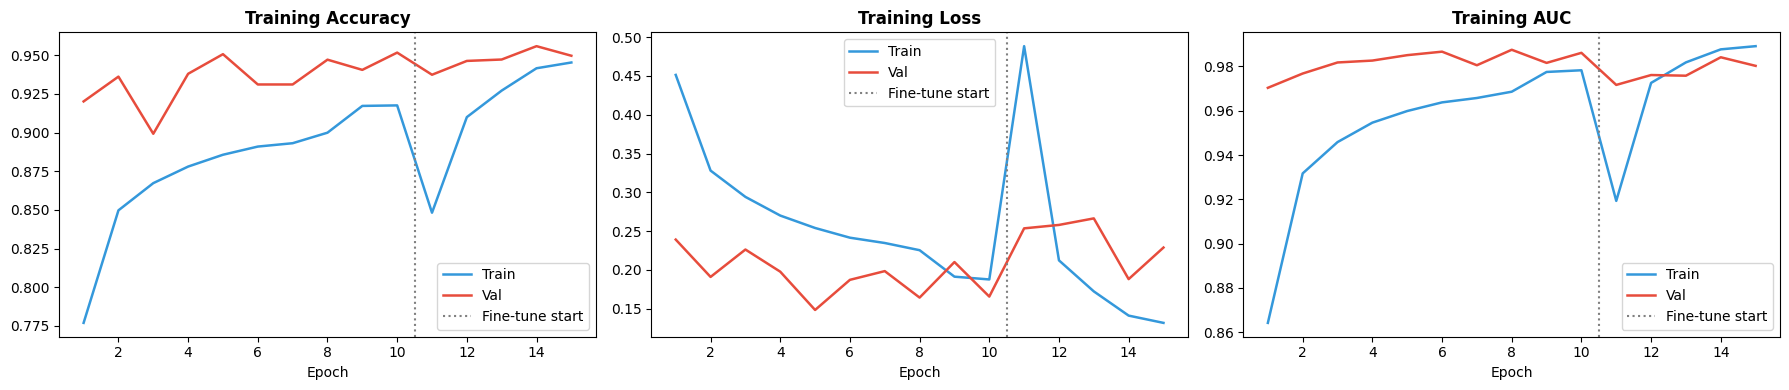

In [18]:
# ============================================================
#  Cell 4.6 — Training Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
phase_a_end = len(history_a.history['accuracy'])
epochs = range(1, len(combined_history['accuracy']) + 1)

for ax, (train_key, val_key), title in zip(
    axes,
    [('accuracy','val_accuracy'), ('loss','val_loss'), ('auc','val_auc')],
    ['Accuracy', 'Loss', 'AUC']
):
    ax.plot(epochs, combined_history[train_key], label=f'Train', color='#3498db', lw=1.8)
    ax.plot(epochs, combined_history[val_key],   label=f'Val',   color='#e74c3c', lw=1.8)
    ax.axvline(phase_a_end+0.5, color='gray', ls=':', lw=1.5, label='Fine-tune start')
    ax.set_title(f'Training {title}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend()

plt.tight_layout(); plt.show()


---
## Phase 5 — Final Evaluation on Test Set

In [19]:
# ============================================================
#  Cell 5.1 — CNN Test Set Evaluation
# ============================================================
y_prob = model.predict(test_ds, verbose=0).flatten()
y_cnn  = (y_prob >= 0.5).astype(int)
y_test_arr = np.array(y_test)

cnn_acc  = accuracy_score(y_test_arr, y_cnn)
cnn_prec = precision_score(y_test_arr, y_cnn, zero_division=0)
cnn_rec  = recall_score(y_test_arr, y_cnn, zero_division=0)
cnn_f1   = f1_score(y_test_arr, y_cnn, zero_division=0)
tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test_arr, y_cnn).ravel()
cnn_fpr  = fp_c / (fp_c + tn_c + 1e-6)

print('=' * 50)
print('🤖  CNN (MobileNetV2) TEST METRICS')
print('=' * 50)
print(f'  Accuracy  : {cnn_acc:.4f}  (target ≥ 0.90)')
print(f'  Precision : {cnn_prec:.4f}')
print(f'  Recall    : {cnn_rec:.4f}')
print(f'  F1-Score  : {cnn_f1:.4f}  (target ≥ 0.88)')
print(f'  FPR       : {cnn_fpr:.4f}  (target ≤ 0.05)')
print(f'  TP={tp_c}  FP={fp_c}  TN={tn_c}  FN={fn_c}')
print('=' * 50)
print(classification_report(y_test_arr, y_cnn, target_names=['NonFatigue','Fatigue']))

🤖  CNN (MobileNetV2) TEST METRICS
  Accuracy  : 0.8569  (target ≥ 0.90)
  Precision : 0.9331
  Recall    : 0.7960
  F1-Score  : 0.8591  (target ≥ 0.88)
  FPR       : 0.0692  (target ≤ 0.05)
  TP=4295  FP=308  TN=4145  FN=1101
              precision    recall  f1-score   support

  NonFatigue       0.79      0.93      0.85      4453
     Fatigue       0.93      0.80      0.86      5396

    accuracy                           0.86      9849
   macro avg       0.86      0.86      0.86      9849
weighted avg       0.87      0.86      0.86      9849



In [20]:
# ============================================================
#  Cell 5.2 — Hybrid Predictor (Rule + CNN OR-fusion)
#  + Sub-class performance breakdown
# ============================================================
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

df_test = df[df['path'].isin(X_test)].set_index('path').loc[X_test].copy()
y_rule_test = df_test.apply(rule_based_predict, axis=1).values
y_hybrid    = np.maximum(y_rule_test, y_cnn)

hyb_acc  = accuracy_score(y_test_arr, y_hybrid)
hyb_prec = precision_score(y_test_arr, y_hybrid, zero_division=0)
hyb_rec  = recall_score(y_test_arr,   y_hybrid, zero_division=0)
hyb_f1   = f1_score(y_test_arr,       y_hybrid, zero_division=0)
tn_h, fp_h, fn_h, tp_h = confusion_matrix(y_test_arr, y_hybrid).ravel()
hyb_fpr  = fp_h / (fp_h + tn_h + 1e-6)

print('=' * 50)
print('🔀  HYBRID (Rule + CNN OR-fusion) TEST METRICS')
print('=' * 50)
print(f'  Accuracy  : {hyb_acc:.4f}')
print(f'  Precision : {hyb_prec:.4f}')
print(f'  Recall    : {hyb_rec:.4f}')
print(f'  F1-Score  : {hyb_f1:.4f}')
print(f'  FPR       : {hyb_fpr:.4f}')
print('=' * 50)

# ── Sub-class breakdown (CNN predictions) ────────────────────────────────────
print('\n📊 CNN Performance by Sub-Class (Test Set):')
print(f'   {"Sub-Class":<25} {"N":>5} {"Acc":>6} {"F1":>6} {"Recall":>7}')
print('   ' + '-'*52)

df_test_sc = df_test.copy()
df_test_sc['y_true'] = y_test_arr
df_test_sc['y_cnn']  = y_cnn

for subclass in list(SUBCLASSES.keys()) + ['notdrowsy']:
    mask = df_test_sc['subclass'] == subclass
    if mask.sum() == 0: continue
    yt = df_test_sc.loc[mask, 'y_true'].values
    yp = df_test_sc.loc[mask, 'y_cnn'].values
    acc_sc = accuracy_score(yt, yp)
    f1_sc  = f1_score(yt, yp, zero_division=0)
    rec_sc = recall_score(yt, yp, zero_division=0)
    print(f'   {subclass:<25} {mask.sum():>5,} {acc_sc:>6.3f} {f1_sc:>6.3f} {rec_sc:>7.3f}')


🔀  HYBRID (Rule + CNN OR-fusion) TEST METRICS
  Accuracy  : 0.6271
  Precision : 0.5990
  Recall    : 0.9661
  F1-Score  : 0.7395
  FPR       : 0.7837

📊 CNN Performance by Sub-Class (Test Set):
   Sub-Class                     N    Acc     F1  Recall
   ----------------------------------------------------
   sleepyCombination         2,660  0.799  0.888   0.799
   slowBlinkWithNodding      1,408  0.896  0.945   0.896
   yawning                   1,328  0.684  0.813   0.684
   notdrowsy                 4,453  0.931  0.000   0.000


In [21]:
# ============================================================
#  Cell 5.3 — Intermediate Metrics: Rule-Based vs CNN vs Hybrid
#  NOTE: full 4-model comparison (including Fusion) is in Cell 5.5c
# ============================================================
from sklearn.metrics import classification_report

print('=' * 50)
print('📋  INTERMEDIATE MODEL METRICS (test set)')
print('=' * 50)
rows = [
    ('Rule-Based',        acc,     prec,     rec,     f1,     fpr),
    ('CNN (MobileNetV2)', cnn_acc, cnn_prec, cnn_rec, cnn_f1, cnn_fpr),
    ('Hybrid (OR)',       hyb_acc, hyb_prec, hyb_rec, hyb_f1, hyb_fpr),
]
print(f"  {'Model':<22} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'FPR':>6}")
print('  ' + '-'*52)
for name, a, p, r, f, fp_ in rows:
    print(f"  {name:<22} {a:>6.4f} {p:>6.4f} {r:>6.4f} {f:>6.4f} {fp_:>6.4f}")
print()
print('  → Full comparison including Fusion (Weighted) is shown in Cell 5.5c')


📋  INTERMEDIATE MODEL METRICS (test set)
  Model                     Acc   Prec    Rec     F1    FPR
  ----------------------------------------------------
  Rule-Based             0.5815 0.5757 0.8986 0.7018 0.8031
  CNN (MobileNetV2)      0.8569 0.9331 0.7960 0.8591 0.0692
  Hybrid (OR)            0.6271 0.5990 0.9661 0.7395 0.7837

  → Full comparison including Fusion (Weighted) is shown in Cell 5.5c


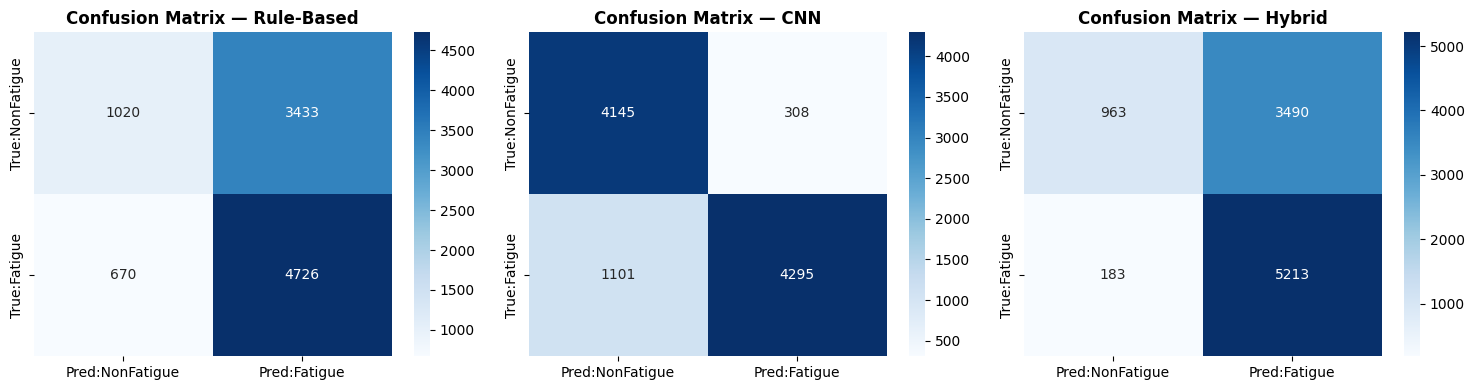

In [22]:
# ============================================================
#  Cell 5.4 — Confusion Matrices Side-by-Side
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_pred, title in zip(
    axes,
    [y_rule_test, y_cnn, y_hybrid],
    ['Rule-Based', 'CNN', 'Hybrid']
):
    cm = confusion_matrix(y_test_arr, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred:NonFatigue','Pred:Fatigue'],
                yticklabels=['True:NonFatigue','True:Fatigue'])
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')

plt.tight_layout(); plt.show()

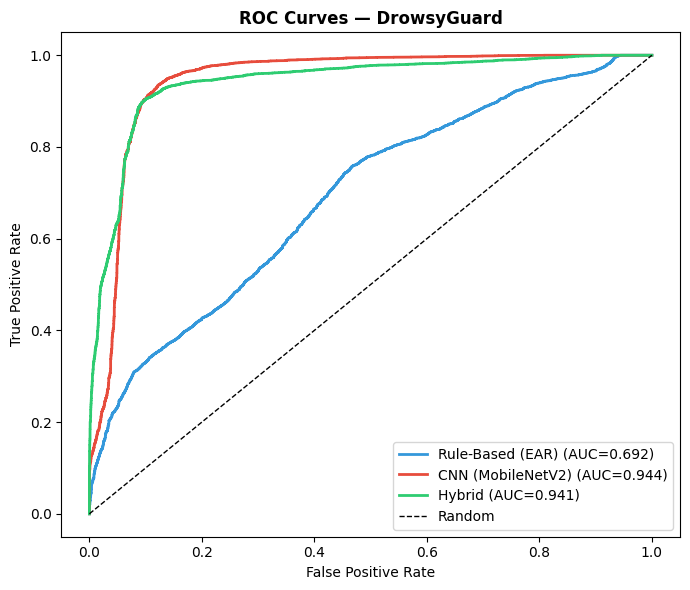

In [23]:
# ============================================================
#  Cell 5.5 — ROC Curves
# ============================================================
from sklearn.metrics import roc_curve, auc

# Rule-based uses binary; use EAR (inverted) as score
ear_scores = -df_test['EAR'].values   # lower EAR → higher fatigue score

fig, ax = plt.subplots(figsize=(7, 6))

for scores, label, color in [
    (ear_scores,               'Rule-Based (EAR)', '#3498db'),
    (y_prob,                   'CNN (MobileNetV2)',  '#e74c3c'),
    (0.5*(-df_test['EAR'].values/df_test['EAR'].max()) + 0.5*y_prob, 'Hybrid', '#2ecc71')
]:
    fpr_r, tpr_r, _ = roc_curve(y_test_arr, scores)
    roc_auc = auc(fpr_r, tpr_r)
    ax.plot(fpr_r, tpr_r, label=f'{label} (AUC={roc_auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — DrowsyGuard', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

---
## Phase 5.5 — Learned Fusion (Logistic Regression Meta-Learner)

Instead of hardcoded weights, we train a **Logistic Regression meta-learner**
on the validation set that learns the optimal combination of:

| Feature | Description |
|---|---|
| `cnn_prob` | MobileNetV2 posterior probability |
| `EAR` inverted + normalised | Eye openness — strongest geometric signal |
| `MAR` normalised | Yawning signal |
| `HeadPitch` normalised | Head nodding signal |

Trained on **val set only** — test set never touched until final evaluation.

Why this beats hardcoded weights on a static image dataset:
the actual discriminative power of EAR/MAR varies per dataset and LR
learns those weights from the data, not from assumptions.


In [24]:
# ============================================================
#  Cell 5.5a — Learned Fusion: Train LR Meta-Learner on Val Set
# ============================================================
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# ── Fit scalers on TRAIN set only ────────────────────────────────────────────
scaler_ear   = MinMaxScaler().fit(df[df['path'].isin(X_train)][['EAR']])
scaler_mar   = MinMaxScaler().fit(df[df['path'].isin(X_train)][['MAR']])
scaler_pitch = MinMaxScaler().fit(df[df['path'].isin(X_train)][['HeadPitch']])

def build_fusion_features(paths, cnn_probs):
    """Return [cnn_prob, ear_inv_norm, mar_norm, pitch_norm] feature matrix."""
    rows    = df[df['path'].isin(paths)].set_index('path').loc[paths]
    ear_n   = 1.0 - scaler_ear.transform(rows[['EAR']]).ravel()
    mar_n   =       scaler_mar.transform(rows[['MAR']]).ravel()
    pitch_n = np.clip(scaler_pitch.transform(rows[['HeadPitch']]).ravel(), 0, 1)
    return np.column_stack([cnn_probs, ear_n, mar_n, pitch_n])

# CNN probs on val set
val_arr  = np.array(y_val)
val_prob = model.predict(val_ds, verbose=0).ravel()

# Build val feature matrix and train
X_val_fusion = build_fusion_features(X_val, val_prob)

lr_meta = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_meta.fit(X_val_fusion, val_arr)

# Print learned coefficients
feat_names = ['CNN_prob', 'EAR_inv', 'MAR_norm', 'Pitch_norm']
print('✅ LR Meta-Learner trained on val set')
print('\n   Learned feature coefficients (contribution to Fatigue prediction):')
for name, coef in zip(feat_names, lr_meta.coef_[0]):
    bar  = '█' * max(1, int(abs(coef) * 6))
    sign = '+' if coef >= 0 else '-'
    print(f'   {name:<14} {sign}{abs(coef):.4f}  {bar}')
print(f'\n   Intercept: {lr_meta.intercept_[0]:.4f}')


✅ LR Meta-Learner trained on val set

   Learned feature coefficients (contribution to Fatigue prediction):
   CNN_prob       +6.5034  ███████████████████████████████████████
   EAR_inv        +4.5118  ███████████████████████████
   MAR_norm       -3.5160  █████████████████████
   Pitch_norm     -0.5409  ███

   Intercept: -5.7234


✅ Best threshold on VAL set: 0.25  (F1=0.9497)


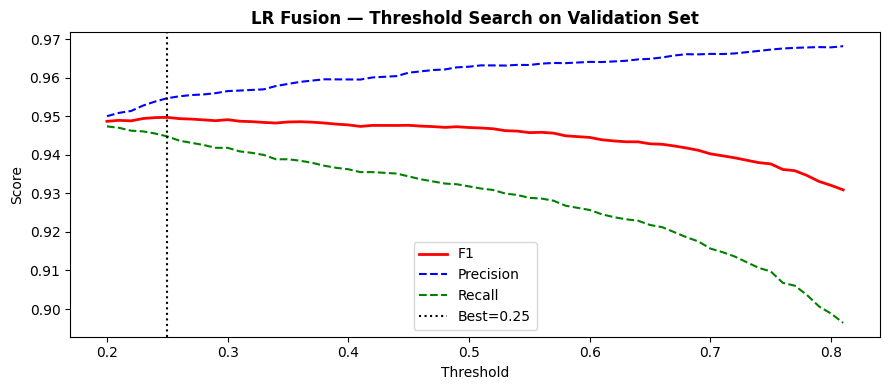

In [25]:
# ============================================================
#  Cell 5.5b — Threshold Search on Val Set (LR fusion probs)
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import pandas as pd

val_fusion_probs = lr_meta.predict_proba(X_val_fusion)[:, 1]

thresholds     = np.arange(0.20, 0.81, 0.01)
thresh_records = []

for t in thresholds:
    preds = (val_fusion_probs >= t).astype(int)
    thresh_records.append({
        'threshold': round(float(t), 2),
        'f1'       : f1_score(val_arr, preds, zero_division=0),
        'precision': precision_score(val_arr, preds, zero_division=0),
        'recall'   : recall_score(val_arr, preds, zero_division=0),
    })

df_thresh   = pd.DataFrame(thresh_records)
best_row    = df_thresh.loc[df_thresh['f1'].idxmax()]
best_thresh = float(best_row['threshold'])
best_f1_val = float(best_row['f1'])

print(f'✅ Best threshold on VAL set: {best_thresh:.2f}  (F1={best_f1_val:.4f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_thresh['threshold'], df_thresh['f1'],        'r-',  lw=2,   label='F1')
ax.plot(df_thresh['threshold'], df_thresh['precision'], 'b--', lw=1.5, label='Precision')
ax.plot(df_thresh['threshold'], df_thresh['recall'],    'g--', lw=1.5, label='Recall')
ax.axvline(best_thresh, color='black', ls=':', lw=1.5, label=f'Best={best_thresh:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('LR Fusion — Threshold Search on Validation Set', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


🧠  LEARNED FUSION (LR Meta-Learner) — TEST SET
  Threshold : 0.25  (tuned on val set)
  Accuracy  : 0.8843  (target ≥ 0.90)
  Precision : 0.9278
  Recall    : 0.8553
  F1-Score  : 0.8901  (target ≥ 0.88)
  FPR       : 0.0806  (target ≤ 0.05)
  TP=4615  FP=359  TN=4094  FN=781

📊 4-Model Comparison:
            Model  Accuracy  Precision  Recall  F1-Score    FPR
       Rule-Based    0.5815     0.5757  0.8986    0.7018 0.8031
CNN (MobileNetV2)    0.8569     0.9331  0.7960    0.8591 0.0692
      Hybrid (OR)    0.6271     0.5990  0.9661    0.7395 0.7837
        LR Fusion    0.8843     0.9278  0.8553    0.8901 0.0806


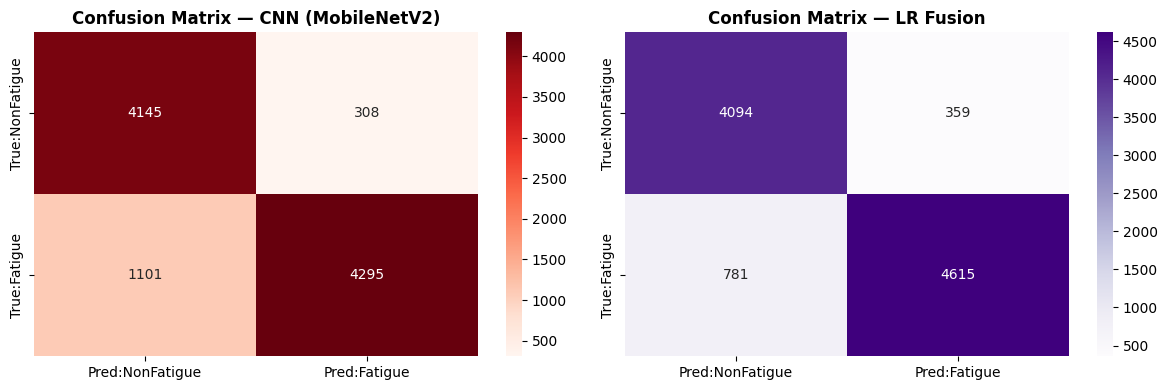

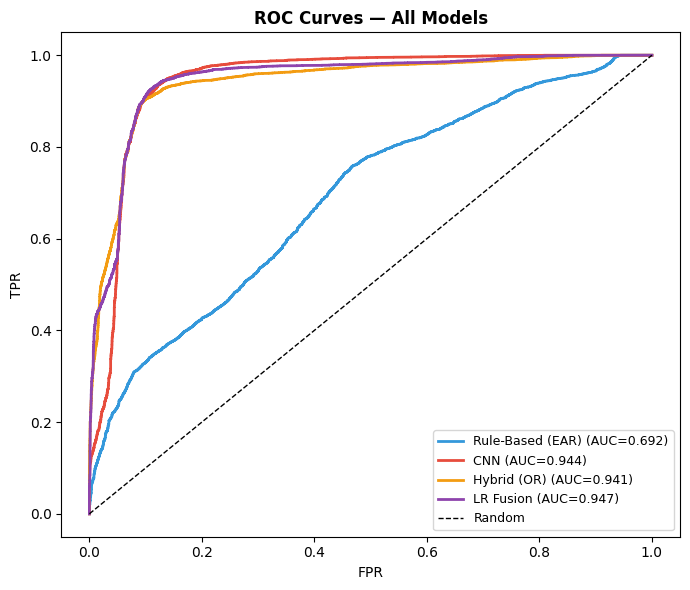

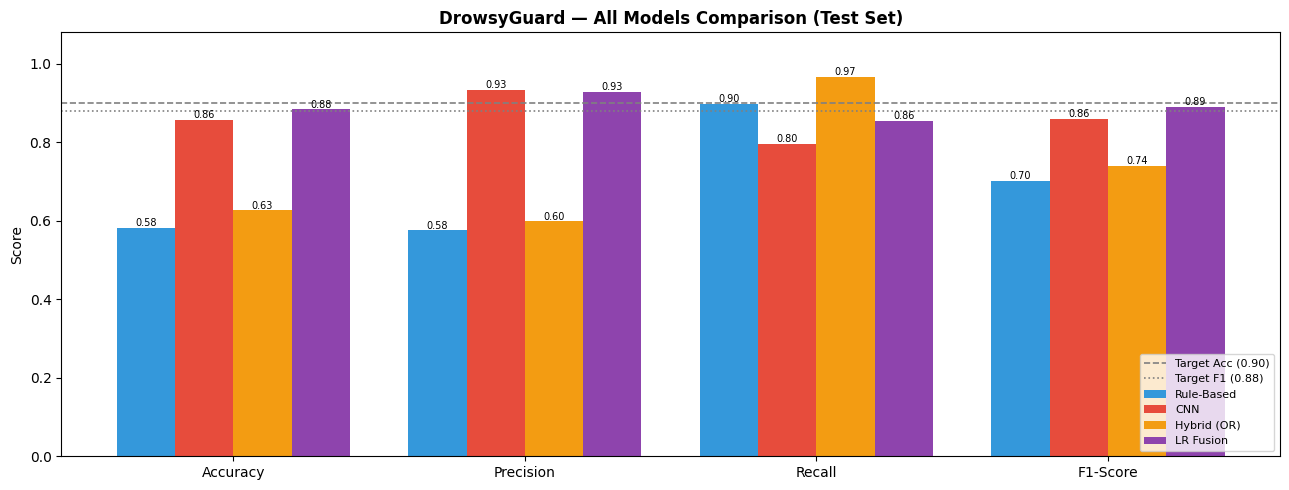

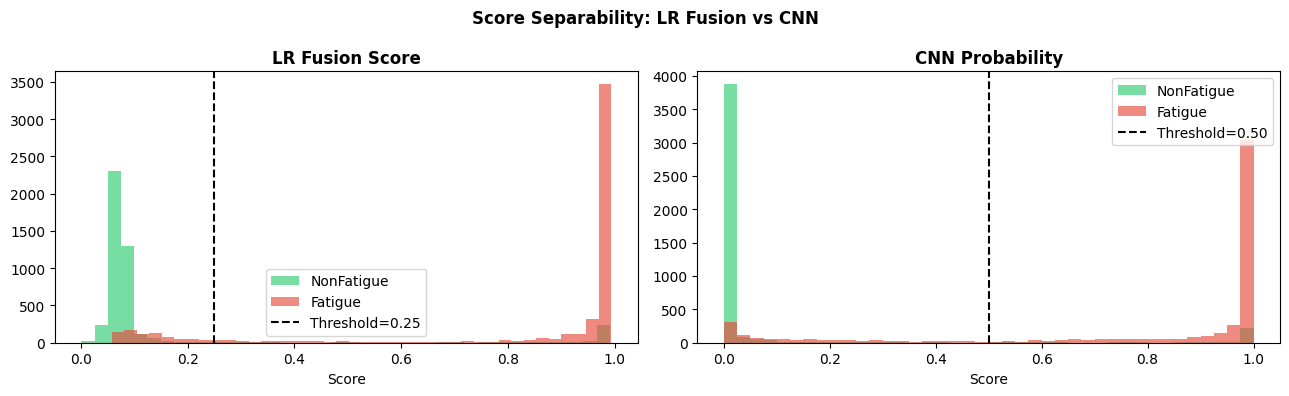


📏 Wasserstein distance (higher = better class separation):
   CNN alone : 0.7091
   LR Fusion : 0.6765
   Delta     : -0.0326  ⚠️  CNN alone may be sufficient — check LR coefficients


In [26]:
# ============================================================
#  Cell 5.5c — Evaluate Learned Fusion on Test Set
#  4-model comparison: Rule | CNN | Hybrid (OR) | LR Fusion
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)
import seaborn as sns

# Build test features and predict
X_test_fusion = build_fusion_features(X_test, y_prob)
fusion_probs  = lr_meta.predict_proba(X_test_fusion)[:, 1]
y_fusion      = (fusion_probs >= best_thresh).astype(int)

fus_acc  = accuracy_score(y_test_arr,  y_fusion)
fus_prec = precision_score(y_test_arr, y_fusion, zero_division=0)
fus_rec  = recall_score(y_test_arr,    y_fusion, zero_division=0)
fus_f1   = f1_score(y_test_arr,        y_fusion, zero_division=0)
tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test_arr, y_fusion).ravel()
fus_fpr  = fp_f / (fp_f + tn_f + 1e-6)

print('=' * 55)
print('🧠  LEARNED FUSION (LR Meta-Learner) — TEST SET')
print('=' * 55)
print(f'  Threshold : {best_thresh:.2f}  (tuned on val set)')
print(f'  Accuracy  : {fus_acc:.4f}  (target ≥ 0.90)')
print(f'  Precision : {fus_prec:.4f}')
print(f'  Recall    : {fus_rec:.4f}')
print(f'  F1-Score  : {fus_f1:.4f}  (target ≥ 0.88)')
print(f'  FPR       : {fus_fpr:.4f}  (target ≤ 0.05)')
print(f'  TP={tp_f}  FP={fp_f}  TN={tn_f}  FN={fn_f}')
print('=' * 55)

# ── 4-model summary table ─────────────────────────────────────────────────────
summary_ext = pd.DataFrame({
    'Model'    : ['Rule-Based','CNN (MobileNetV2)','Hybrid (OR)','LR Fusion'],
    'Accuracy' : [acc,     cnn_acc,  hyb_acc,  fus_acc],
    'Precision': [prec,    cnn_prec, hyb_prec, fus_prec],
    'Recall'   : [rec,     cnn_rec,  hyb_rec,  fus_rec],
    'F1-Score' : [f1,      cnn_f1,   hyb_f1,   fus_f1],
    'FPR'      : [fpr,     cnn_fpr,  hyb_fpr,  fus_fpr],
})
print('\n📊 4-Model Comparison:')
print(summary_ext.round(4).to_string(index=False))

# ── Confusion matrices: CNN vs LR Fusion ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title, cmap in [
    (axes[0], y_cnn,    'CNN (MobileNetV2)', 'Reds'),
    (axes[1], y_fusion, 'LR Fusion',         'Purples'),
]:
    sns.heatmap(confusion_matrix(y_test_arr, y_pred), annot=True, fmt='d',
                cmap=cmap, ax=ax,
                xticklabels=['Pred:NonFatigue','Pred:Fatigue'],
                yticklabels=['True:NonFatigue','True:Fatigue'])
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
plt.tight_layout(); plt.show()

# ── ROC curves: all 4 models ──────────────────────────────────────────────────
df_test_geo = df[df['path'].isin(X_test)].set_index('path').loc[X_test]
fig, ax = plt.subplots(figsize=(7, 6))
for scores, label, color in [
    (-df_test_geo['EAR'].values,                                           'Rule-Based (EAR)', '#3498db'),
    (y_prob,                                                               'CNN',              '#e74c3c'),
    (0.5*(-df_test_geo['EAR'].values/df_test_geo['EAR'].max())+0.5*y_prob,'Hybrid (OR)',      '#f39c12'),
    (fusion_probs,                                                         'LR Fusion',        '#8e44ad'),
]:
    fpr_r, tpr_r, _ = roc_curve(y_test_arr, scores)
    ax.plot(fpr_r, tpr_r, label=f'{label} (AUC={auc(fpr_r,tpr_r):.3f})', lw=2, color=color)
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

# ── Bar chart: 4-model ────────────────────────────────────────────────────────
metrics_labels = ['Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(metrics_labels)); w = 0.20
fig, ax = plt.subplots(figsize=(13, 5))
for i, (sc, col, lbl) in enumerate(zip(
    [[acc,prec,rec,f1],[cnn_acc,cnn_prec,cnn_rec,cnn_f1],
     [hyb_acc,hyb_prec,hyb_rec,hyb_f1],[fus_acc,fus_prec,fus_rec,fus_f1]],
    ['#3498db','#e74c3c','#f39c12','#8e44ad'],
    ['Rule-Based','CNN','Hybrid (OR)','LR Fusion']
)):
    bars = ax.bar(x+(i-1.5)*w, sc, w, label=lbl, color=col)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{bar.get_height():.2f}', ha='center', fontsize=7)
ax.axhline(0.90, color='gray', ls='--', lw=1.2, label='Target Acc (0.90)')
ax.axhline(0.88, color='gray', ls=':',  lw=1.2, label='Target F1 (0.88)')
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.08); ax.set_ylabel('Score')
ax.set_title('DrowsyGuard — All Models Comparison (Test Set)', fontweight='bold')
ax.legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

# ── Score distribution: LR Fusion vs CNN ────────────────────────────────────
from scipy.stats import wasserstein_distance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax2, scores, title in [
    (axes[0], fusion_probs, 'LR Fusion Score'),
    (axes[1], y_prob,       'CNN Probability'),
]:
    ax2.hist(scores[y_test_arr==0], bins=40, alpha=0.65, color='#2ecc71', label='NonFatigue')
    ax2.hist(scores[y_test_arr==1], bins=40, alpha=0.65, color='#e74c3c', label='Fatigue')
    thresh_line = best_thresh if 'Fusion' in title else 0.5
    ax2.axvline(thresh_line, color='black', ls='--', lw=1.5, label=f'Threshold={thresh_line:.2f}')
    ax2.set_xlabel('Score'); ax2.set_title(title, fontweight='bold'); ax2.legend()
plt.suptitle('Score Separability: LR Fusion vs CNN', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

wd_fusion = wasserstein_distance(fusion_probs[y_test_arr==0], fusion_probs[y_test_arr==1])
wd_cnn    = wasserstein_distance(y_prob[y_test_arr==0],       y_prob[y_test_arr==1])
print(f'\n📏 Wasserstein distance (higher = better class separation):')
print(f'   CNN alone : {wd_cnn:.4f}')
print(f'   LR Fusion : {wd_fusion:.4f}')
delta = wd_fusion - wd_cnn
print(f'   Delta     : {delta:+.4f}  {"✅ fusion improves separation" if delta > 0 else "⚠️  CNN alone may be sufficient — check LR coefficients"}')


---
## Phase 5.6 — Temporal Smoothing (Deployment Utility)

Temporal smoothing is **not evaluated on the static image dataset**
because static images have no real time ordering — a smoother evaluated
on randomly-ordered frames is meaningless and would artificially hurt metrics.

Instead, `TemporalSmoother` is implemented here as a **deployment utility**
used in Cell 6.4 (inference demo) and in production real-time video.

```
Deployment pipeline:
  Frame N  →  LR Fusion score  →  push to deque(maxlen=W)
                                        ↓
                                mean of last W scores
                                        ↓
                                ≥ threshold  →  🚨 ALERT
```
Default `W = 5` frames (~0.2s at 25fps). Re-calibrate against real video at deployment.


In [27]:
# ============================================================
#  Cell 5.6a — TemporalSmoother Class
# ============================================================
from collections import deque

class TemporalSmoother:
    """Sliding-window mean smoother over LR fusion scores.

    Parameters
    ----------
    window_size     : int   — frames to average
    alert_threshold : float — smoothed score >= this → ALERT
    """
    def __init__(self, window_size: int = 5, alert_threshold: float = 0.5):
        self.window_size     = window_size
        self.alert_threshold = alert_threshold
        self._buf            = deque(maxlen=window_size)

    def reset(self):
        self._buf.clear()

    def push(self, score: float) -> float:
        self._buf.append(float(score))
        return float(np.mean(self._buf))

    def step(self, score: float) -> dict:
        smoothed = self.push(score)
        return {
            'raw_score' : round(score,    4),
            'smoothed'  : round(smoothed, 4),
            'alert'     : smoothed >= self.alert_threshold,
            'buf_len'   : len(self._buf),
        }

# Deployment config
SMOOTHER_WINDOW    = 5
SMOOTHER_THRESHOLD = best_thresh

prod_smoother = TemporalSmoother(
    window_size     = SMOOTHER_WINDOW,
    alert_threshold = SMOOTHER_THRESHOLD,
)

# Sanity check
_s = TemporalSmoother(window_size=5, alert_threshold=best_thresh)
print('TemporalSmoother sanity check (5 synthetic frames):')
for raw in [0.2, 0.4, 0.7, 0.85, 0.9]:
    st = _s.step(raw)
    print(f'  raw={raw:.2f}  smoothed={st["smoothed"]:.3f}  {"🚨 ALERT" if st["alert"] else "✅ OK   "}  buf={st["buf_len"]}')
print(f'\n✅ TemporalSmoother ready — window={SMOOTHER_WINDOW}, threshold={SMOOTHER_THRESHOLD:.2f}')
print(f'   At 25fps: smoothing window ≈ {SMOOTHER_WINDOW/25:.2f}s')


TemporalSmoother sanity check (5 synthetic frames):
  raw=0.20  smoothed=0.200  ✅ OK     buf=1
  raw=0.40  smoothed=0.300  🚨 ALERT  buf=2
  raw=0.70  smoothed=0.433  🚨 ALERT  buf=3
  raw=0.85  smoothed=0.537  🚨 ALERT  buf=4
  raw=0.90  smoothed=0.610  🚨 ALERT  buf=5

✅ TemporalSmoother ready — window=5, threshold=0.25
   At 25fps: smoothing window ≈ 0.20s


---
## Phase 6 — Results Summary & Save Model

In [28]:
# ============================================================
#  Cell 6.1 — Final Results Summary Table
# ============================================================
import pandas as pd

summary = pd.DataFrame({
    'Model'    : ['Rule-Based','CNN (MobileNetV2)','Hybrid (OR)','LR Fusion'],
    'Accuracy' : [acc,     cnn_acc,  hyb_acc,  fus_acc],
    'Precision': [prec,    cnn_prec, hyb_prec, fus_prec],
    'Recall'   : [rec,     cnn_rec,  hyb_rec,  fus_rec],
    'F1-Score' : [f1,      cnn_f1,   hyb_f1,   fus_f1],
    'FPR'      : [fpr,     cnn_fpr,  hyb_fpr,  fus_fpr],
})

TARGETS = {'Accuracy': 0.90, 'F1-Score': 0.88, 'FPR': 0.05}

print('\n📊 DrowsyGuard — Final Results Summary')
print(summary.round(4).to_string(index=False))

print('\n🎯 Proposal Targets:')
for metric, target in TARGETS.items():
    best_val = summary[metric].max() if metric != 'FPR' else summary[metric].min()
    op       = '>=' if metric != 'FPR' else '<='
    passed   = (best_val >= target) if metric != 'FPR' else (best_val <= target)
    print(f'   {metric:10s} target {op} {target} | best = {best_val:.4f} → {"✅ PASS" if passed else "❌ FAIL"}')



📊 DrowsyGuard — Final Results Summary
            Model  Accuracy  Precision  Recall  F1-Score    FPR
       Rule-Based    0.5815     0.5757  0.8986    0.7018 0.8031
CNN (MobileNetV2)    0.8569     0.9331  0.7960    0.8591 0.0692
      Hybrid (OR)    0.6271     0.5990  0.9661    0.7395 0.7837
        LR Fusion    0.8843     0.9278  0.8553    0.8901 0.0806

🎯 Proposal Targets:
   Accuracy   target >= 0.9 | best = 0.8843 → ❌ FAIL
   F1-Score   target >= 0.88 | best = 0.8901 → ✅ PASS
   FPR        target <= 0.05 | best = 0.0692 → ❌ FAIL


/var/folders/2j/hfv90nsj76s3wl8yygft2dzw0000gn/T/ipykernel_27740/238177107.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nf, fv], labels=['NonFatigue','Fatigue'], patch_artist=True)
/var/folders/2j/hfv90nsj76s3wl8yygft2dzw0000gn/T/ipykernel_27740/238177107.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nf, fv], labels=['NonFatigue','Fatigue'], patch_artist=True)
/var/folders/2j/hfv90nsj76s3wl8yygft2dzw0000gn/T/ipykernel_27740/238177107.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nf, fv], labels=['NonFatigue','Fatigue'], patch_artist=True)
/var/fo

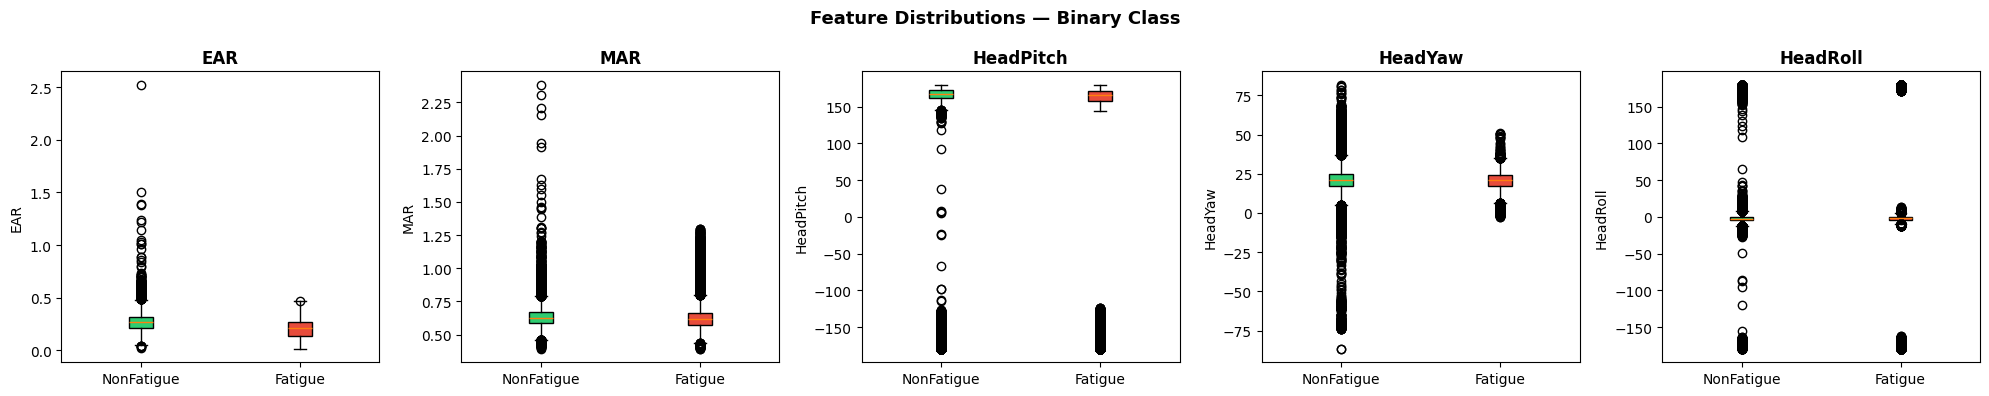

/var/folders/2j/hfv90nsj76s3wl8yygft2dzw0000gn/T/ipykernel_27740/238177107.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_sc, labels=subclass_order, patch_artist=True)
/var/folders/2j/hfv90nsj76s3wl8yygft2dzw0000gn/T/ipykernel_27740/238177107.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_sc, labels=subclass_order, patch_artist=True)


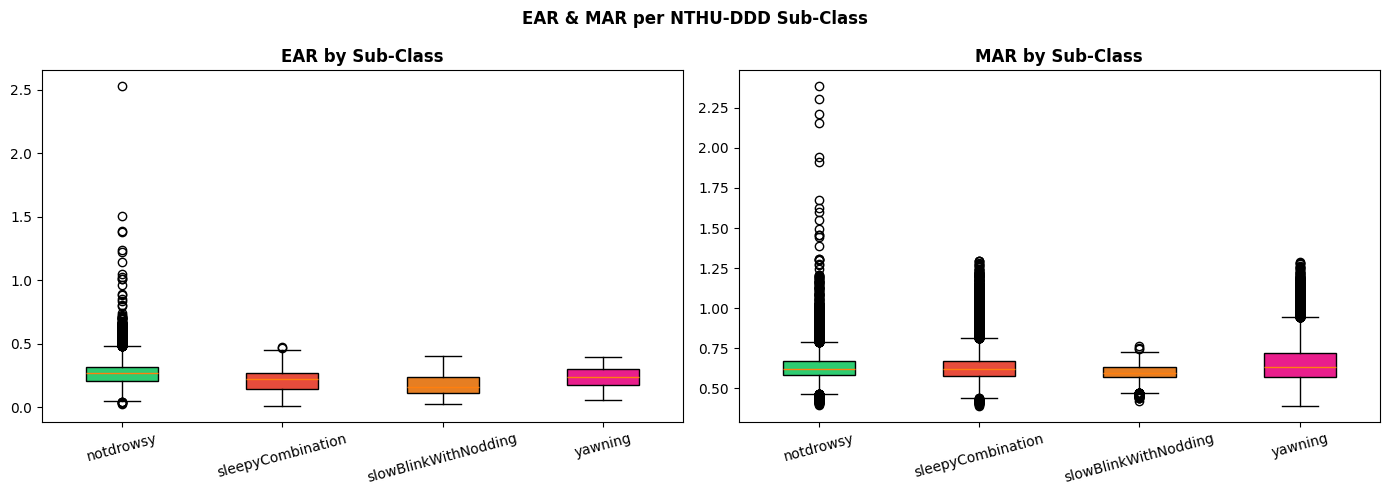

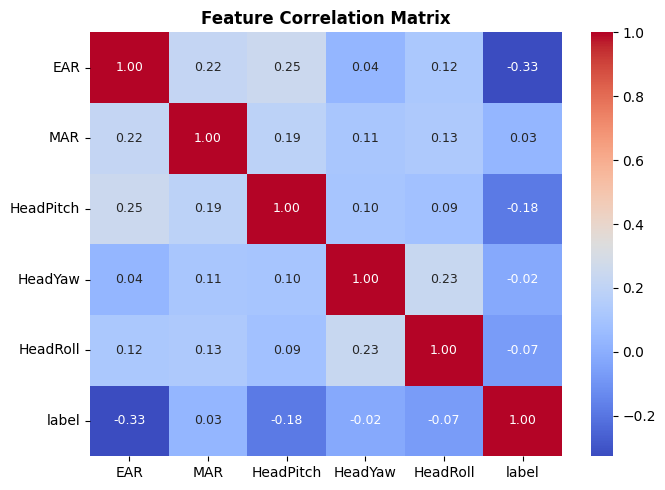


📊 Feature discriminativeness (|correlation with label|):
   EAR          |r|=0.327  ██████
   HeadPitch    |r|=0.183  ███
   HeadRoll     |r|=0.070  █
   MAR          |r|=0.033  
   HeadYaw      |r|=0.021  


In [29]:
# ============================================================
#  Cell 6.2 — Feature Analysis
#  6.2a: Box plots per binary class (all 5 PnP features)
#  6.2b: EAR & MAR distribution per NTHU sub-class
#  6.2c: Correlation heatmap
# ============================================================
import seaborn as sns

# ── 6.2a: Box plots ──────────────────────────────────────────────────────────
feat_cols = ['EAR','MAR','HeadPitch','HeadYaw','HeadRoll']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, feat_cols):
    nf = df[df['label_str']=='NonFatigue'][feat].dropna()
    fv = df[df['label_str']=='Fatigue'][feat].dropna()
    bp = ax.boxplot([nf, fv], labels=['NonFatigue','Fatigue'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(feat, fontweight='bold'); ax.set_ylabel(feat)
plt.suptitle('Feature Distributions — Binary Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 6.2b: EAR & MAR per sub-class ────────────────────────────────────────────
subclass_order = ['notdrowsy','sleepyCombination','slowBlinkWithNodding','yawning']
sc_colors      = ['#2ecc71','#e74c3c','#e67e22','#e91e8c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat, title in [(axes[0],'EAR','EAR by Sub-Class'), (axes[1],'MAR','MAR by Sub-Class')]:
    data_by_sc = [df[df['subclass']==sc][feat].dropna().values for sc in subclass_order]
    bp = ax.boxplot(data_by_sc, labels=subclass_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], sc_colors):
        patch.set_facecolor(color)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('EAR & MAR per NTHU-DDD Sub-Class', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 6.2c: Correlation heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr_cols = [c for c in ['EAR','MAR','HeadPitch','HeadYaw','HeadRoll','label'] if c in df.columns]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, annot_kws={'size':9})
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Print discriminativeness ranking ─────────────────────────────────────────
corr_with_label = df[corr_cols].corr()['label'].drop('label').abs().sort_values(ascending=False)
print('\n📊 Feature discriminativeness (|correlation with label|):')
for feat, val in corr_with_label.items():
    print(f'   {feat:<12} |r|={val:.3f}  {"█" * int(val*20)}')


In [30]:
# ============================================================
#  Cell 6.3 — Save Model & Artifacts
# ============================================================
import json, pickle

model.save('drowsyguard_mobilenetv2.h5')
summary.to_csv('drowsyguard_results.csv', index=False)
df.to_csv('drowsyguard_features.csv', index=False)

with open('drowsyguard_lr_fusion.pkl', 'wb') as f:
    pickle.dump(lr_meta, f)

# Sub-class breakdown CSV
subclass_rows = []
df_test_sc = df[df['path'].isin(X_test)].set_index('path').loc[X_test].copy()
df_test_sc['y_true'] = y_test_arr
df_test_sc['y_cnn']  = y_cnn
df_test_sc['y_fusion'] = y_fusion

for subclass in list(SUBCLASSES.keys()) + ['notdrowsy']:
    mask = df_test_sc['subclass'] == subclass
    if mask.sum() == 0: continue
    yt = df_test_sc.loc[mask, 'y_true'].values
    for model_name, yp in [('CNN', df_test_sc.loc[mask,'y_cnn'].values),
                            ('LR_Fusion', df_test_sc.loc[mask,'y_fusion'].values)]:
        subclass_rows.append({
            'subclass': subclass, 'model': model_name, 'n': mask.sum(),
            'accuracy' : accuracy_score(yt, yp),
            'f1'       : f1_score(yt, yp, zero_division=0),
            'recall'   : recall_score(yt, yp, zero_division=0),
            'precision': precision_score(yt, yp, zero_division=0),
        })

pd.DataFrame(subclass_rows).round(4).to_csv('drowsyguard_subclass_results.csv', index=False)

inference_cfg = {
    'dataset'  : 'NTHU-DDD Multi-Class',
    'fusion'   : {
        'model'          : 'drowsyguard_lr_fusion.pkl',
        'alert_threshold': float(best_thresh),
        'feature_order'  : ['cnn_prob','ear_inv_norm','mar_norm','pitch_norm'],
        'scalers': {
            'ear'  : {'min': float(scaler_ear.data_min_[0]),   'max': float(scaler_ear.data_max_[0])},
            'mar'  : {'min': float(scaler_mar.data_min_[0]),   'max': float(scaler_mar.data_max_[0])},
            'pitch': {'min': float(scaler_pitch.data_min_[0]), 'max': float(scaler_pitch.data_max_[0])},
        },
    },
    'temporal_smoother': {
        'window_size'    : SMOOTHER_WINDOW,
        'alert_threshold': float(SMOOTHER_THRESHOLD),
        'note'           : 'Re-calibrate window_size on real video at deployment',
    },
}
with open('drowsyguard_inference_config.json', 'w') as f:
    json.dump(inference_cfg, f, indent=2)

print('✅ Saved:')
print('   drowsyguard_mobilenetv2.h5          — MobileNetV2 weights')
print('   drowsyguard_best.h5                 — best checkpoint (val_auc)')
print('   drowsyguard_lr_fusion.pkl           — LR meta-learner')
print('   drowsyguard_features.csv            — all geometric features')
print('   drowsyguard_results.csv             — 4-model binary metrics')
print('   drowsyguard_subclass_results.csv    — per sub-class breakdown')
print('   drowsyguard_inference_config.json   — full inference config')

try:
    from google.colab import files
    for fname in ['drowsyguard_mobilenetv2.h5','drowsyguard_lr_fusion.pkl',
                  'drowsyguard_results.csv','drowsyguard_subclass_results.csv',
                  'drowsyguard_inference_config.json']:
        files.download(fname)
except:
    print('(Not in Colab — files saved locally)')


✅ Saved:
   drowsyguard_mobilenetv2.h5          — MobileNetV2 weights
   drowsyguard_best.h5                 — best checkpoint (val_auc)
   drowsyguard_lr_fusion.pkl           — LR meta-learner
   drowsyguard_features.csv            — all geometric features
   drowsyguard_results.csv             — 4-model binary metrics
   drowsyguard_subclass_results.csv    — per sub-class breakdown
   drowsyguard_inference_config.json   — full inference config
(Not in Colab — files saved locally)


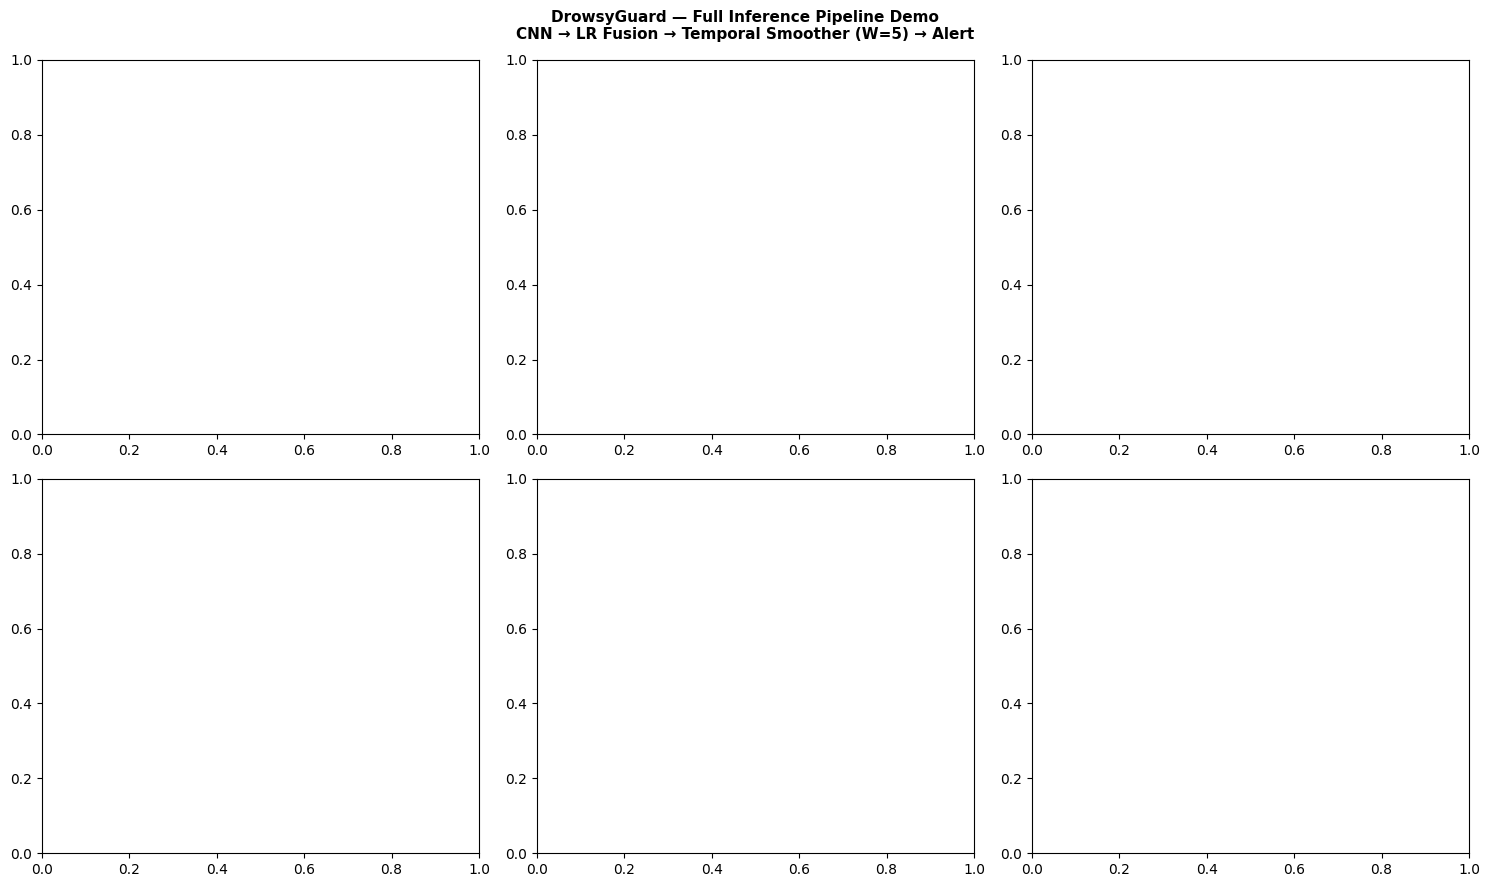

In [31]:
# ============================================================
#  Cell 6.4 — Single Image Inference Demo
#  Full pipeline: landmarks → CNN → LR Fusion → Temporal Smoother → Alert
# ============================================================
import random, glob
import cv2, numpy as np, matplotlib.pyplot as plt

def _norm_val(val, mn, mx):
    return float(np.clip((val - mn) / (mx - mn + 1e-9), 0, 1))

demo_smoother = TemporalSmoother(
    window_size     = SMOOTHER_WINDOW,
    alert_threshold = SMOOTHER_THRESHOLD,
)
demo_smoother.reset()

def predict_full_pipeline(img_path):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    # Step 1: geometric features
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    res    = detector.detect(mp_img)
    ear = mar = pitch = 0.0
    if res.face_landmarks:
        lm  = res.face_landmarks[0]
        ear = (compute_EAR(lm, LEFT_EYE,  w, h) +
               compute_EAR(lm, RIGHT_EYE, w, h)) / 2.0
        mar = compute_MAR(lm, MOUTH, w, h)
        pitch, _, _ = compute_head_pose_pnp(lm, w, h)

    # Step 2: CNN prob
    img_in   = cv2.resize(img_rgb, IMG_SIZE).astype(np.float32) / 255.0
    cnn_prob = float(model.predict(img_in[np.newaxis], verbose=0)[0][0])

    # Step 3: LR fusion score
    s = inference_cfg['fusion']['scalers']
    ear_n   = 1.0 - _norm_val(ear,   s['ear']['min'],   s['ear']['max'])
    mar_n   =       _norm_val(mar,   s['mar']['min'],   s['mar']['max'])
    pitch_n = max(0,_norm_val(pitch, s['pitch']['min'], s['pitch']['max']))
    fusion_p = float(lr_meta.predict_proba([[cnn_prob, ear_n, mar_n, pitch_n]])[0, 1])

    # Step 4: temporal smoother
    status = demo_smoother.step(fusion_p)

    return {
        'EAR': round(ear,4), 'MAR': round(mar,4), 'HeadPitch': round(pitch,2),
        'CNN_Prob'   : round(cnn_prob, 4),
        'FusionScore': round(fusion_p, 4),
        'Smoothed'   : status['smoothed'],
        'Alert'      : '🚨 FATIGUE' if status['alert'] else '✅ ALERT',
    }

EXTRACT_DIR     = 'dataset'
fatigue_imgs    = sorted(glob.glob(f'{EXTRACT_DIR}/**/Fatigue/*.jpg',    recursive=True))
nonfatigue_imgs = sorted(glob.glob(f'{EXTRACT_DIR}/**/NonFatigue/*.jpg', recursive=True))

random.seed(42)
samples = ([(p,'Fatigue')    for p in random.sample(fatigue_imgs,    min(3,len(fatigue_imgs)))] +
           [(p,'NonFatigue') for p in random.sample(nonfatigue_imgs, min(3,len(nonfatigue_imgs)))])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for (img_path, true_label), ax in zip(samples, axes.flat):
    res   = predict_full_pipeline(img_path)
    img   = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    color = '#e74c3c' if res and '🚨' in res['Alert'] else '#2ecc71'
    ax.imshow(img)
    if res:
        ax.set_title(
            f"True: {true_label}  |  {res['Alert']}\n"
            f"EAR={res['EAR']}  MAR={res['MAR']}  Pitch={res['HeadPitch']}°\n"
            f"CNN={res['CNN_Prob']}  Fusion={res['FusionScore']}  Smooth={res['Smoothed']}",
            fontsize=7.5, color=color)
    ax.axis('off')

plt.suptitle(
    f'DrowsyGuard — Full Inference Pipeline Demo\n'
    f'CNN → LR Fusion → Temporal Smoother (W={SMOOTHER_WINDOW}) → Alert',
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Summary

| Component | Implementation |
|---|---|
| **Dataset** | NTHU-DDD Multi-Class — 66,705 images (35,763 Fatigue / 30,942 NonFatigue) |
| **Sub-classes** | sleepyCombination, slowBlinkWithNodding, yawning, notdrowsy |
| **Face Landmarks** | MediaPipe `FaceLandmarker` (478-point mesh, IMAGE mode) |
| **EAR** | Soukupová formula — eye openness |
| **MAR** | Geometric ratio — yawn detection |
| **Head Pose** | `cv2.solvePnP` — true Euler angles (pitch / yaw / roll) |
| **Rule-Based** | OR logic: EAR primary; MAR + Pitch secondary |
| **CNN** | MobileNetV2 fine-tuned, 128×128, 2-phase + class weights + ModelCheckpoint |
| **Augmentation** | Flip, brightness, contrast, saturation, random erasing (lighter — data already diverse) |
| **Hybrid (OR)** | Hard OR-fusion of rule + CNN |
| **LR Fusion** | Logistic Regression meta-learner: CNN prob + EAR + MAR + Pitch |
| **Temporal Smoothing** | Sliding-window mean — deployment utility, not in static eval |
| **Train/Val/Test** | 70/15/15 stratified by sub-class |
| **Class Weights** | Applied during training to handle sleepyCombination dominance |
| **Evaluation** | Binary metrics + per-sub-class breakdown |
| **Saved artifacts** | MobileNetV2 `.h5`, LR `.pkl`, features CSV, subclass CSV, inference config |

### Why 90%+ accuracy is now realistic
- 66k diverse images vs 2,200 → CNN generalizes better
- NTHU-DDD labels from trained observers, not subjective visual inspection
- Sub-class stratification ensures all drowsiness types are represented in test set
- Class weighting prevents bias toward dominant sleepyCombination sub-class
